## Calculating R* using SciKit Leanrn's HistGradientBoostClassifier Model. 


The first step is to load in a MaCh3 MCMC fit as input file. This is done using the ChainHandler class!

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory
from MaCh3PythonUtils.file_handling.chain_diagnostics import ChainDiagnostics
from sklearn.model_selection import LearningCurveDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import log_loss    


# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import random as rand
import os
import pandas as pd
import seaborn as sns
import gdown
import arviz as az

Using mps device

### Adding Chain IDs to each individual chains

I am working with MCMC chains generated from T2K-like and NOvA-like data. The folders contain non-adaptive and adaptive MCMC chains, both of which have its own T2K and NOvA runs. TLDR; the code grabs each file in the user-specified folder and then adds Chain IDs to them.

- Once the user has defined the path to the directory that contains the .root files (chain files), the code below takes each .root file in that directory and passes it through a `ChainHandler` instance which can manipulate what data Python is able to read; adds and removes plots. 

- It then adds the Chain IDs onto the seperate files; IDs start from 0 and end at N for N files in that directory. The IDs are for the ML Classifier. 
- Finally, it stitches all the files into one big pandas DataFrame; this is what the model is trained and tested on.

In [ ]:

#file_url="https://drive.google.com/file/d/1iE6xFhn3BH_HnLUfQ7KFGy2wfeH52Rwf/view?usp=sharing"


path_NoAd_T2K= Path("../models/demo_files 2/NoAdapt/T2K")
path_NoAd_Nova= Path('../models/demo_files 2/NoAdapt/NOvA')
path_Ad_T2K= Path('../models/demo_files 2/Adapt/T2K')
path_Ad_Nova= Path('../models/demo_files 2/Adapt/NOvA')

NAD_T2K=[f"{path_NoAd_T2K}/{x}" for x in os.listdir(path_NoAd_T2K)] 
NAD_Nova=[f'{path_NoAd_Nova}/{y}' for y in os.listdir(path_NoAd_Nova)]
AD_T2K=[f'{path_Ad_T2K}/{z}' for z in os.listdir(path_Ad_T2K)]
AD_Nova=[f'{path_Ad_Nova}/{a}' for a in os.listdir(path_Ad_Nova)]# these will be used later as args in functions (used to calc the dims of the data)

print(NAD_T2K)
print(NAD_Nova)
print(AD_T2K)
print(AD_Nova)


fitting_label = "ID"
paths = [NAD_T2K, NAD_Nova, AD_T2K, AD_Nova]
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

TEMP_NAD_T2K_list = []
TEMP_NAD_Nova_list = []
TEMP_AD_T2K_list = []
TEMP_AD_Nova_list = []

for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(["xsec_20", "xsec_19", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp', 'baseline', 'density', 'Ye'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == NAD_T2K:
            TEMP_NAD_T2K_list.append(chain_handler)
        elif lm == NAD_Nova:
            TEMP_NAD_Nova_list.append(chain_handler)
        elif lm == AD_T2K:
            TEMP_AD_T2K_list.append(chain_handler)
        elif lm == AD_Nova:
            TEMP_AD_Nova_list.append(chain_handler)


NAD_T2K_data = TEMP_NAD_T2K_list[0]
NAD_T2K_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

NAD_Nova_data = TEMP_NAD_Nova_list[0]
NAD_Nova_data.ttree_array['ID']= 0

AD_T2K_data = TEMP_AD_T2K_list[0]
AD_T2K_data.ttree_array['ID']= 0

AD_Nova_data = TEMP_AD_Nova_list[0]
AD_Nova_data.ttree_array['ID']= 0


for id, chain in enumerate(TEMP_NAD_T2K_list[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
    NAD_T2K_data.ttree_array = pd.concat([NAD_T2K_data.ttree_array, chain.ttree_array])

for ida, chains in enumerate(TEMP_NAD_Nova_list[1:], start = 1): 
    #add ID to chain['id']
    chains.ttree_array['ID'] = ida
    #chains.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chains.ttree_array))*1.2
    NAD_Nova_data.ttree_array = pd.concat([NAD_Nova_data.ttree_array, chains.ttree_array])

for idb, chainss in enumerate(TEMP_AD_T2K_list[1:], start = 1): 
    #add ID to chain['id']
    chainss.ttree_array['ID'] = idb
    #chainss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainss.ttree_array))*1.2
    AD_T2K_data.ttree_array = pd.concat([AD_T2K_data.ttree_array, chainss.ttree_array])

for idc, chainsss in enumerate(TEMP_AD_Nova_list[1:], start = 1): 
    #add ID to chain['id']
    chainsss.ttree_array['ID'] = idc
    #chainsss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainsss.ttree_array))*1.2
    AD_Nova_data.ttree_array = pd.concat([AD_Nova_data.ttree_array, chainsss.ttree_array])

#from now on, the files that include out data that are now usable are: NAD_T2K_data, NAD_Nova_data, AD_T2K_data, AD_Nova_data


## Machine learning: Scikit Learn, HistGradientBoostingClassifier (GBT)

Now that we have done some file manipulation, we can start doing some Machine Learning:

We start by initialising an instance of `MLFactory `. `MLFactory` is essentially a script that contains different ML Models that can be called upon request. We pass the fitting label (which is 'ID') and the DataFrame containing all the .root files to create the instance. We do this for every folder (T2K, NOvA)

In [ ]:
# First step we need to initialise the factory
path_NoAd_T2K.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_NADT2K = MLFactory(NAD_T2K_data, fitting_label, f"{path_NoAd_T2K}.pdf")


path_NoAd_Nova.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_NADNova = MLFactory(NAD_Nova_data, fitting_label, f"{path_NoAd_Nova}.pdf")



path_Ad_T2K.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_ADT2K = MLFactory(AD_T2K_data, fitting_label, f"{path_Ad_T2K}.pdf")


path_Ad_Nova.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_ADNova = MLFactory(AD_Nova_data, fitting_label, f"{path_Ad_Nova}.pdf")



Now we have an instance of MLFactory for every dataset, we need to create an interface that passes important parameters as arguments such as the model type, learning rate, max leaf node, loss type, etc. Here, we have chosen the histboostclass as the model as the R* diagnostic works the best via gradient boosted trees.

<div class="alert alert-block alert-success">
<b>Note:</b> Both Random Forest and Gradient Boosted Trees work the best for the R* diagnostic; however, RF work well with low complexity, low dimensional datasets whereas for larger datasets with a higher complexity, GBT work better.


In [ ]:



#ml_model_NADT2K = ml_factory_NADT2K.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=12, verbose=2, max_leaf_nodes=30, 
                                                   #l2_regularization= 0.1, validation_fraction= 0.3, early_stopping=True, n_iter_no_change= 10)
#ml_model_NADT2K.set_training_test_set(0.2)


#ml_model_NADNova = ml_factory_NADNova.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=50, verbose=2, max_leaf_nodes=30)
#ml_model_NADNova.set_training_test_set(0.3)

#ml_model_ADT2K = ml_factory_ADT2K.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=100, verbose=2, max_leaf_nodes=250)
#ml_model_ADT2K.set_training_test_set(0.3)

#ml_model_ADNova = ml_factory_ADNova.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
#ml_model_ADNova.set_training_test_set(0.3)


In [ ]:
#training the model
#ml_model_NADT2K.train_model()

#scikitmodel_NADT2K= ml_model_NADT2K.model #assigns the model (histboostclass) to a variable; able to access and use the model directly 
#ml_model_NADT2K.test_model_class(NAD_T2K, 'noadapt', 't2k', norm= False, model=ml_model_NADT2K)#test function 


'''
scikitmodel_NADNova= ml_model_NADNova.model
scikitmodel_ADT2K= ml_model_ADT2K.model
scikitmodel_NADNova= ml_model_ADNova.model
'''


#ml_model_NADT2K.plot_loss(scikitmodel_NADT2K)# plots the loss function 



#LearningCurveDisplay.from_estimator( #prints out how well model learns when you give it a training size of 50000, 100000 etx (out of 1 million)
#   scikitmodel_NADT2K, ml_model_NADT2K._training_data, ml_model_NADT2K._training_labels, train_sizes=[50000, 100000, 900000], cv=2) 


## Adaptive versus Non-Adaptive: Visual Comparison
The `ChainDiagnostics` class is used here to plot how an MCMC looks like from a chosen dataset and parameter. 

The plots on the left are called **Trace Plots**. 

> Trace plots visually represent the evolution of parameter values over iterations of Markov Chains.

The x-axis is the step number of the MCMC (note that each tick is that value multiplied by 1e6), and the y-axis shows the actual physical value of a propery of the neutrino. Trace plots help asses how well-mixed the chains are by seeing whether the chains have explored the target distribution adequately.

One can see that the main difference are that the Adaptive MCMC travels through more of the posterioir than the non-adaptive; the Adaptive MCMC oscillates around `1.0` more times per step than the Non-Adaptive.

> The plots on the right are **Histogram** plots and it is just the Trace plots integrated. 

The number of times the MCMC grabs a particular value is then plotted as the Histogram plot. From the Trace plot, one can deduce that the chain "crosses" `1.0` the most, thus the peak of the Hist plot is at `1.0`. 

<div class="alert alert-block alert-success">
<b>Note:</b> One might expect that for different algorithms (i.e non-adaptive versus adaptive), both trace plots and the histogram plots should look different. However, the non-adaptive and adaptive MCMCs are based off of the same physical system, thus the only difference is their algorithm, which is distinguished in the trace plot. Histogram plots are usually identify general trends that are present in a physical systems.

In [ ]:
#plotter_NADT2K=ChainDiagnostics(NAD_T2K_data)

#plotter_ADT2K=ChainDiagnostics(AD_T2K_data)
#plotter_NADT2K("xsec_10")
#plotter_ADT2K("xsec_10")
#plt.show()

In [2]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_identical= Path("../models/demo_files 2/all_on_ADT2K/identical/")
path_to_1= Path("../models/demo_files 2/all_on_ADT2K/level 1/")
path_to_2= Path("../models/demo_files 2/all_on_ADT2K/level 2/")
path_to_3= Path("../models/demo_files 2/all_on_ADT2K/level 3/")
path_to_4= Path("../models/demo_files 2/all_on_ADT2K/level 4/")
path_to_5= Path("../models/demo_files 2/all_on_ADT2K/level 5/")
path_to_6= Path("../models/demo_files 2/all_on_ADT2K/level 6/")
path_to_7= Path("../models/demo_files 2/all_on_ADT2K/level 7/")

identical=[f"{path_to_identical}/{x}" for x in os.listdir(path_to_identical)] 
level1=[f'{path_to_1}/{y}' for y in os.listdir(path_to_1)]
level2=[f'{path_to_2}/{z}' for z in os.listdir(path_to_2)]
level3=[f'{path_to_3}/{a}' for a in os.listdir(path_to_3)]# these will be used later as args in functions (used to calc the dims of the data)
level4=[f'{path_to_4}/{b}' for b in os.listdir(path_to_4)]
level5=[f'{path_to_5}/{c}' for c in os.listdir(path_to_5)]
level6=[f'{path_to_6}/{b}' for b in os.listdir(path_to_6)]
level7=[f'{path_to_7}/{c}' for c in os.listdir(path_to_7)]




fitting_label = "ID"
paths = [identical, level1, level2, level3, level4,level5, level6, level7]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]
temp1=[]
temp2=[]
temp3=[]
temp4=[]
temp5=[]
temp6=[]
temp7=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(["xsec_20", "xsec_19", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp', 'baseline', 'density', 'Ye'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
        #chain_handler.add_additional_plots(['sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == identical:
            temp_identical.append(chain_handler)
        elif lm == level1:
            temp1.append(chain_handler)
        elif lm == level2:
            temp2.append(chain_handler)
        elif lm == level3:
            temp3.append(chain_handler)
        elif lm == level4:
            temp4.append(chain_handler)
        elif lm == level5:
            temp5.append(chain_handler)
        elif lm == level6:
            temp6.append(chain_handler)
        elif lm == level7:
            temp7.append(chain_handler)




entire_data = temp_identical[0] #entire_data is intially the first identical dataset that you want to attach the rest of the chain files onto
identical_data= temp_identical[1]
entire_data.ttree_array['ID']= 0 
identical_data.ttree_array['ID']=1

entire_data.ttree_array= pd.concat([entire_data.ttree_array, identical_data.ttree_array])


level1_data = temp1[0]
level1_data.ttree_array['ID']= 2
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level1_data.ttree_array[f'xsec_{m}']= level1_data.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level1_data.ttree_array[f'xsec_{m}']))*0.00001)
entire_data.ttree_array = pd.concat([entire_data.ttree_array, level1_data.ttree_array])



level2_data = temp2[0]
level2_data.ttree_array['ID']= 3
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level2_data.ttree_array[f'xsec_{m}']= level2_data.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level2_data.ttree_array[f'xsec_{m}']))*0.0001)
entire_data.ttree_array = pd.concat([entire_data.ttree_array, level2_data.ttree_array])

level3_data = temp3[0]
level3_data.ttree_array['ID']= 4

for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level3_data.ttree_array[f'xsec_{m}']= level3_data.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level3_data.ttree_array[f'xsec_{m}']))*0.001)
entire_data.ttree_array = pd.concat([entire_data.ttree_array, level3_data.ttree_array])

level4_data= temp4[0]
level4_data.ttree_array['ID']=5
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level4_data.ttree_array[f'xsec_{m}']= level4_data.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level4_data.ttree_array[f'xsec_{m}']))*0.01)
entire_data.ttree_array = pd.concat([entire_data.ttree_array, level4_data.ttree_array])

level5_data= temp5[0]
level5_data.ttree_array['ID']=6
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level5_data.ttree_array[f'xsec_{m}']= level5_data.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level5_data.ttree_array[f'xsec_{m}']))*0.1)
entire_data.ttree_array = pd.concat([entire_data.ttree_array, level5_data.ttree_array])

level6_data= temp6[0]
level6_data.ttree_array['ID']=7
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level6_data.ttree_array[f'xsec_{m}']= level6_data.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level6_data.ttree_array[f'xsec_{m}'])))
entire_data.ttree_array = pd.concat([entire_data.ttree_array, level6_data.ttree_array])

level7_data= temp7[0]
level7_data.ttree_array['ID']=8
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level7_data.ttree_array[f'xsec_{m}']= level7_data.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level7_data.ttree_array[f'xsec_{m}']))*10)
entire_data.ttree_array = pd.concat([entire_data.ttree_array, level7_data.ttree_array])


print(entire_data.ttree_array)

'''
for id, chain in enumerate(temp_identical[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
identical_data.ttree_array = pd.concat([identical_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp1[1:], start = 3): 
    
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.00001)
    level1_data.ttree_array = pd.concat([level1_data.ttree_array, chain.ttree_array])
    entire_data.ttree_array= pd.concat([entire_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp2[1:], start = 5): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.0001)
    level2_data.ttree_array = pd.concat([level2_data.ttree_array, chain.ttree_array])
    entire_data.ttree_array= pd.concat([entire_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp3[1:], start = 7): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.001)
    level3_data.ttree_array = pd.concat([level3_data.ttree_array, chain.ttree_array])
    entire_data.ttree_array= pd.concat([entire_data.ttree_array, chain.ttree_array])


    
for id, chain in enumerate(temp4[1:], start = 9): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.01)
    level4_data.ttree_array = pd.concat([level4_data.ttree_array, chain.ttree_array])
    entire_data.ttree_array= pd.concat([entire_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp5[1:], start = 11): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.1)
    level5_data.ttree_array = pd.concat([level5_data.ttree_array, chain.ttree_array])
    entire_data.ttree_array= pd.concat([entire_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp6[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}'])))
    level6_data.ttree_array = pd.concat([level6_data.ttree_array, chain.ttree_array])
    entire_data.ttree_array= pd.concat([entire_data.ttree_array, chain.ttree_array])



for id, chain in enumerate(temp7[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*10)
    level7_data.ttree_array = pd.concat([level7_data.ttree_array, chain.ttree_array])
    entire_data.ttree_array= pd.concat([entire_data.ttree_array, chain.ttree_array])
'''


['../models/demo_files 2/all_on_ADT2K/identical/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/identical/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 1/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 1/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 2/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 2/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 3/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 3/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 4/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 4/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 5/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 5/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 6/mcmc_Adapt_T2K_all_on_copy

"\nfor id, chain in enumerate(temp_identical[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1\n    #add ID to chain['id']\n    chain.ttree_array['ID'] = id\n    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1\nidentical_data.ttree_array = pd.concat([identical_data.ttree_array, chain.ttree_array])\n\n\nfor id, chain in enumerate(temp1[1:], start = 3): \n    \n    chain.ttree_array['ID'] = id\n    for m in range(23):\n        if m == 19:\n            continue\n        elif m == 20:\n            continue\n        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.00001)\n    level1_data.ttree_array = pd.concat([level1_data.ttree_array, chain.ttree_array])\n    entire_data.ttree_array=

In [3]:

# First step we need to initialise the factory
path_to_identical.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_id = MLFactory(entire_data, fitting_label, f"{path_to_identical}.pdf")
'''
#hook up paths to MLFactory
path_to_1.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level1 = MLFactory(level1_data, fitting_label, f"{path_to_1}.pdf")

path_to_2.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level2 = MLFactory(level2_data, fitting_label, f"{path_to_2}.pdf")

path_to_3.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level3 = MLFactory(level3_data, fitting_label, f"{path_to_3}.pdf")

path_to_4.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level4 = MLFactory(level4_data, fitting_label, f"{path_to_4}.pdf")

path_to_5.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level5 = MLFactory(level5_data, fitting_label, f"{path_to_5}.pdf")

path_to_6.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level6 = MLFactory(level6_data, fitting_label, f"{path_to_6}.pdf")

path_to_7.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level7 = MLFactory(level7_data, fitting_label, f"{path_to_7}.pdf")
'''

ID


'\n#hook up paths to MLFactory\npath_to_1.parent.mkdir(parents=True, exist_ok=True)\nprint(fitting_label)\nml_factory_level1 = MLFactory(level1_data, fitting_label, f"{path_to_1}.pdf")\n\npath_to_2.parent.mkdir(parents=True, exist_ok=True)\nprint(fitting_label)\nml_factory_level2 = MLFactory(level2_data, fitting_label, f"{path_to_2}.pdf")\n\npath_to_3.parent.mkdir(parents=True, exist_ok=True)\nprint(fitting_label)\nml_factory_level3 = MLFactory(level3_data, fitting_label, f"{path_to_3}.pdf")\n\npath_to_4.parent.mkdir(parents=True, exist_ok=True)\nprint(fitting_label)\nml_factory_level4 = MLFactory(level4_data, fitting_label, f"{path_to_4}.pdf")\n\npath_to_5.parent.mkdir(parents=True, exist_ok=True)\nprint(fitting_label)\nml_factory_level5 = MLFactory(level5_data, fitting_label, f"{path_to_5}.pdf")\n\npath_to_6.parent.mkdir(parents=True, exist_ok=True)\nprint(fitting_label)\nml_factory_level6 = MLFactory(level6_data, fitting_label, f"{path_to_6}.pdf")\n\npath_to_7.parent.mkdir(parents=T

## How does R* behave when 2 identical chain files slowly become more random.
> At what value of R* can we say with confidence that the ML Classifier distinguishes between the 2 chains as good as random guessing.

I have 8 files that each initially contain the exact same chain data. 

Training Model
Binning 0.874 GB of training data: 2.105 s
Binning 0.097 GB of validation data: 0.179 s
Fitting gradient boosted rounds:
[1/20] 9 trees, 3999 leaves (444 on avg), max depth = 35, train loss: 2.14808, val loss: 2.14817, in 5.550s
[2/20] 9 trees, 4008 leaves (445 on avg), max depth = 40, train loss: 2.10281, val loss: 2.10298, in 5.319s
[3/20] 9 trees, 4010 leaves (445 on avg), max depth = 40, train loss: 2.06068, val loss: 2.06093, in 5.325s
[4/20] 9 trees, 4006 leaves (445 on avg), max depth = 35, train loss: 2.02146, val loss: 2.02179, in 4.903s
[5/20] 9 trees, 4007 leaves (445 on avg), max depth = 32, train loss: 1.98470, val loss: 1.98509, in 4.556s
[6/20] 9 trees, 4006 leaves (445 on avg), max depth = 33, train loss: 1.94991, val loss: 1.95036, in 4.554s
[7/20] 9 trees, 4000 leaves (444 on avg), max depth = 31, train loss: 1.91718, val loss: 1.91770, in 4.699s
[8/20] 9 trees, 4003 leaves (444 on avg), max depth = 31, train loss: 1.88610, val loss: 1.88667, in 4.649s


[[230320 268052 110931  15112  17394    138      2      0      0]
 [228246 270583 110880  15259  17587    134      1      0      0]
 [186583 233978 166600  35321  19411    134      3      0      0]
 [104785 151406 116289 212987  56287    247      1      0      0]
 [ 36026  52259  41445  71307 434712   6567      2      0      0]
 [  1166   1311   1988   1808  29067 606861    445      0      0]
 [     8     10     16     24    225   6994 634193     53      0]
 [     0      0      0      0      0      3     43 641556     14]
 [     0      0      0      0      0      0      0      2 642628]]

9

length of id list:9

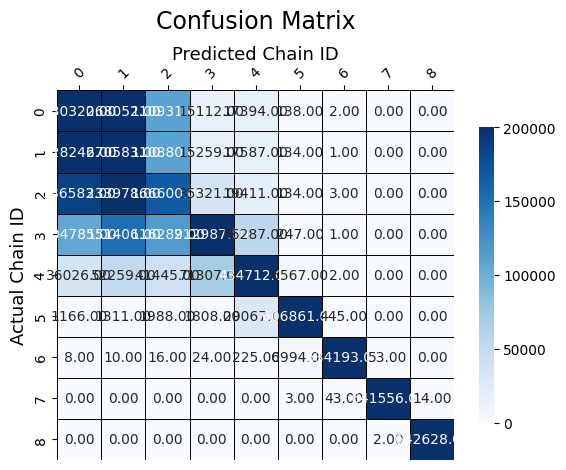

predictive accuracy: 0.6645045060009648

R*: 5.316036048007718

=====

Testing Results!

[[ 55886  68174  28068   4077   4509     31      1      0      0]
 [ 57960  65643  28119   3930   4316     35      2      0      0]
 [ 46829  59015  40638   9044   5097     42      0      0      0]
 [ 26450  38051  29484  52305  14337     66      0      0      0]
 [  9086  13264  10234  18062 108019   1712      0      0      0]
 [   290    299    521    466   7307 151028    138      0      0]
 [     3      3      2      7     55   1805 159282     15      0]
 [     0      0      0      0      0      0     20 161056      3]
 [     0      0      0      0      0      0      0      0 160065]]

9

length of id list:9

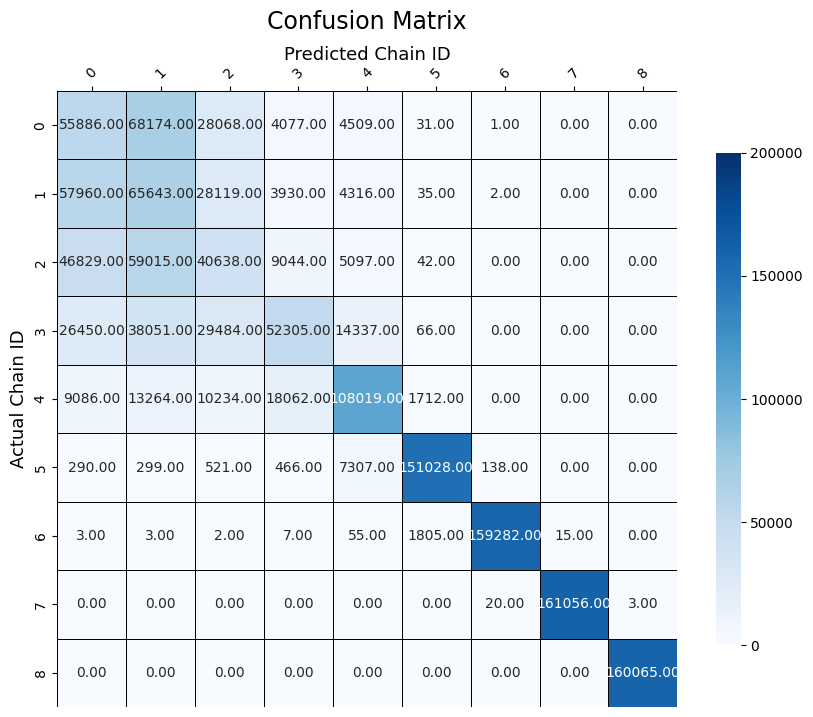

predictive accuracy: 0.66022171144291

R*: 5.28177369154328

=====

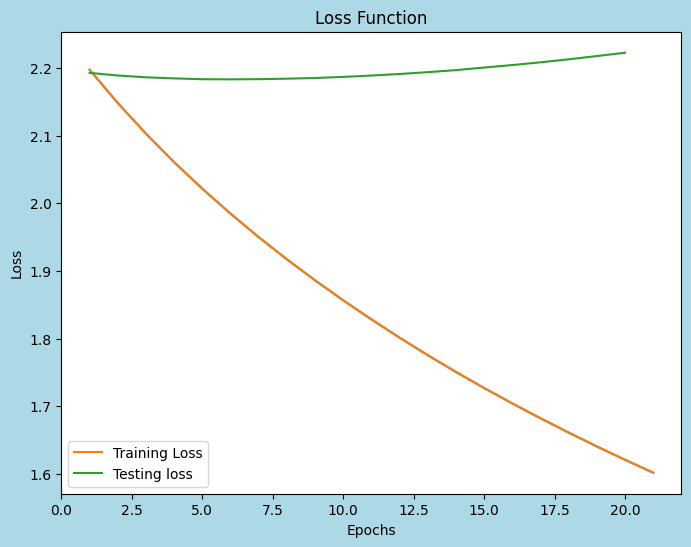

"\nml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=2, max_leaf_nodes=220, \n                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data\nml_model_1.set_training_test_set(0.3)\nml_model_1.train_model()\nprint(f'results for level 1:')\nprint('=========================')\nml_model_1.test_model_class(level1, 'adapt', 't2k', norm= False, model=ml_model_1)\n\n\nml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=2, max_leaf_nodes=100, \n                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)\nml_model_2.set_training_test_set(0.3)\nml_model_2.train_model()\nprint(f'results for level 2:')\nprint('========================='

In [4]:


ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=20, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_id.set_training_test_set(0.2)
ml_model_id.train_model()
print(f'results for identical:')
print('=========================')
ml_model_id.test_model_class(8, norm= False, model=ml_model_id)




'''
ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=2, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data
ml_model_1.set_training_test_set(0.3)
ml_model_1.train_model()
print(f'results for level 1:')
print('=========================')
ml_model_1.test_model_class(level1, 'adapt', 't2k', norm= False, model=ml_model_1)


ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=2, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_2.set_training_test_set(0.3)
ml_model_2.train_model()
print(f'results for level 2:')
print('=========================')
ml_model_2.test_model_class(level2, 'adapt', 't2k', norm= False, model=ml_model_2)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=2, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_3.set_training_test_set(0.3)
ml_model_3.train_model()
print(f'results for level 3:')
print('=========================')
ml_model_3.test_model_class(level3, 'adapt', 't2k', norm= False, model=ml_model_3)


ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=2, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_4.set_training_test_set(0.3)
ml_model_4.train_model()
print(f'results for level 4:')
print('=========================')

ml_model_4.test_model_class(level4, 'adapt', 't2k', norm= False, model=ml_model_4)




ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=2, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_5.set_training_test_set(0.3)
ml_model_5.train_model()
print(f'results for level 5:')
print('=========================')
ml_model_5.test_model_class(level5, 'adapt', 't2k', norm= False, model=ml_model_5)


ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=2, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_6.set_training_test_set(0.3)
ml_model_6.train_model()
print(f'results for level 6:')
print('=========================')
ml_model_6.test_model_class(level6, 'adapt', 't2k', norm= False, model=ml_model_6) 


ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.001, max_iter=20, verbose=2, max_leaf_nodes=630, 
                                                   l2_regularization= 0.0, max_features= 0.3, early_stopping=True, n_iter_no_change= 10)
ml_model_7.set_training_test_set(0.3)
ml_model_7.train_model()
print(f'results for level 7:')
print('=========================')
ml_model_7.test_model_class(level7, 'adapt', 't2k', norm= False, model=ml_model_7)
'''

### Run the cell below for diagnostics: Confusion Matrix, Loss function plots, etc

In [ ]:

ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', validation_fraction= 0.39999999999999986, n_iter_no_change= 200, max_leaf_nodes= 210, max_iter= 9, max_features= 0.8, learning_rate= 0.2736, l2_regularization= 0.848)



ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', validation_fraction= 0.9899999999999995, n_iter_no_change= 200, max_leaf_nodes= 520, max_iter= 7, max_features= 0.6000000000000001, learning_rate= 0.0118, l2_regularization= 0.17400000000000002)#contains level1 data



ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', validation_fraction= 0.9799999999999995, n_iter_no_change= 200, max_leaf_nodes= 290, max_iter= 5, max_features= 0.30000000000000004, learning_rate= 0.10070000000000001, l2_regularization= 0.485)


ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', validation_fraction= 0.39999999999999986, n_iter_no_change= 200, max_leaf_nodes= 680, max_iter= 4, max_features= 0.8, learning_rate= 0.0959, l2_regularization= 0.899)



ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', validation_fraction= 0.7199999999999998, n_iter_no_change= 200, max_leaf_nodes= 500, max_iter= 6, max_features= 0.30000000000000004, learning_rate= 0.0563, l2_regularization= 0.001)





ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', validation_fraction= 0.18999999999999995, n_iter_no_change= 200, max_leaf_nodes= 490, max_iter= 8, max_features= 0.6000000000000001, learning_rate= 0.0729, l2_regularization= 0.193)


ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', validation_fraction= 0.38999999999999985, n_iter_no_change= 200, max_leaf_nodes= 570, max_iter= 8, max_features= 0.30000000000000004, learning_rate= 0.2074, l2_regularization= 0.386)
 


ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', validation_fraction= 0.33, learning_rate= 0.033400000000000006, max_iter=200, verbose=2, max_leaf_nodes=63, 
max_features= 0.4, early_stopping=True, n_iter_no_change= 7)







In [ ]:

ml_model_id.set_training_test_set(0.3)
ml_model_id.train_model()
print(f'results for identical:')
print('=========================')
ml_model_id.test_model_class(identical,'adapt', 't2k', norm=  False, model= ml_model_id)
ml_model_1.set_training_test_set(0.3)
ml_model_1.train_model()
print(f'results for level 1:')
print('=========================')
ml_model_1.test_model_class(level1, 'adapt', 't2k', norm= False, model=ml_model_1)
ml_model_2.set_training_test_set(0.3)
ml_model_2.train_model()
print(f'results for level 2:')
print('=========================')
ml_model_2.test_model_class(level2, 'adapt', 't2k', norm= False, model=ml_model_2)
ml_model_3.set_training_test_set(0.3)
ml_model_3.train_model()
print(f'results for level 3:')
print('=========================')
ml_model_3.test_model_class(level3, 'adapt', 't2k', norm= False, model=ml_model_3)
ml_model_4.set_training_test_set(0.3)
ml_model_4.train_model()
print(f'results for level 4:')
print('=========================')

ml_model_4.test_model_class(level4, 'adapt', 't2k', norm= False, model=ml_model_4)
ml_model_5.set_training_test_set(0.2)
ml_model_5.train_model()
print(f'results for level 5:')
print('=========================')
ml_model_5.test_model_class(level5, 'adapt', 't2k', norm=  False, model=ml_model_5)

ml_model_6.set_training_test_set(0.2)
ml_model_6.train_model()
print(f'results for level 6:')
print('=========================')
ml_model_6.test_model_class(level6, 'adapt', 't2k', norm= False, model=ml_model_6)

ml_model_7.set_training_test_set(0.2)
ml_model_7.train_model()
print(f'results for level 7:')
print('=========================')
ml_model_7.test_model_class(level7, 'adapt', 't2k', norm= False, model=ml_model_7)


In [ ]:
'''
dist={
        'learning_rate': np.arange(0.0001, 0.3, 0.0001 ),
        'max_leaf_nodes': [i for i in range(20, 700, 10)],
        'max_features': np.arange(0.1, 1, 0.1),
        'l2_regularization': np.arange(0.001, 1, 0.001), 
        'max_iter': [i for i in range(1, 20, 1)],
        'validation_fraction':np.arange(0.1, 1, 0.01),
        'n_iter_no_change': [i for i in range(1, 20, 1)]
    }

models = [ml_model_id, ml_model_1, ml_model_2, ml_model_3, ml_model_4, ml_model_5, ml_model_6, ml_model_7]


for model in models:
    clf = RandomizedSearchCV(estimator=model.model, param_distributions=dist, cv=5, n_iter=2)
    search = clf.fit(model.scale_data(model._training_data), model.scale_labels(model._training_labels))
    print(f"Best params for {model}: {search.best_params_}")
    
    
'''

### Calc multiple R* vals for each level and then plot them with error bars

In [ ]:
ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=20, verbose=1, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=1, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data)
ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=1, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=1, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=1, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=20, verbose=1, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
list_id=[]
list1=[]
list2=[]
list3=[]
list4=[]
list5=[]
list6=[]
list7=[]


datapoints= 10
for i in range(datapoints):
    ml_model_id.set_training_test_set(0.3)
    ml_model_id.train_model()
    y=ml_model_id.getRStar_vals(identical, ml_model_id)
    list_id.append(y)

for i in range(datapoints):
    ml_model_1.set_training_test_set(0.3)
    ml_model_1.train_model()
    y=ml_model_1.getRStar_vals(level1, ml_model_1)
    list1.append(y)

for i in range(datapoints):
    ml_model_2.set_training_test_set(0.3)
    ml_model_2.train_model()
    y=ml_model_2.getRStar_vals(level2, ml_model_2)
    list2.append(y)

for i in range(datapoints):
    ml_model_3.set_training_test_set(0.3)
    ml_model_3.train_model()
    y=ml_model_3.getRStar_vals(level3, ml_model_3)
    list3.append(y)

for i in range(datapoints):
    ml_model_4.set_training_test_set(0.3)
    ml_model_4.train_model()
    y=ml_model_4.getRStar_vals(level4, ml_model_4)
    list4.append(y)

for i in range(datapoints):
    ml_model_5.set_training_test_set(0.3)
    ml_model_5.train_model()
    y=ml_model_5.getRStar_vals(level5, ml_model_5)
    list5.append(y)

for i in range(datapoints):
    ml_model_6.set_training_test_set(0.3)
    ml_model_6.train_model()
    y=ml_model_6.getRStar_vals(level6, ml_model_6)
    list6.append(y)
    

for i in range(datapoints):
    ml_model_7.set_training_test_set(0.3)
    ml_model_7.train_model()
    y=ml_model_7.getRStar_vals(identical, ml_model_7)
    list7.append(y)





In [ ]:

lists=[list_id, list1, list2, list3, list4, list5, list6, list7]
concat= list_id + list1 + list2 + list3 + list4 + list5 + list6 +list7

means = np.array([np.mean(vals) for vals in lists])
mins  = np.array([np.min(vals)  for vals in lists])
maxs  = np.array([np.max(vals)  for vals in lists])

lower_err = means - mins
upper_err = maxs  - means
yerr = np.vstack((lower_err, upper_err))


x = np.arange(len(lists)) + 2   

plt.errorbar(x, means,
             yerr=yerr,
             fmt='o',        
             capsize=5,      
             elinewidth=0.5,
             markeredgewidth=0.5)


labels = ['identical',r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$']
datapoints = 2
def add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.
    return x + np.random.uniform(-scale, scale, size=len(x))

for xi, vals in zip(x, lists):
    jittered =    jittered_x = add_jitter([xi]*len(vals), scale=0.1)
    plt.scatter(jittered, vals, alpha=0.3, s=30)

plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], [labels[0], labels[1], labels[2], labels[3], labels[4], labels[5], labels[6], labels[7]])

ymin, ymax = min(concat), max(concat)
pad    = (ymax - ymin) * 0.2
plt.ylim(ymin - pad, ymax + pad)
plt.ylim(min(list1)-0.1, max(list7)+0.1)

plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   
plt.rcParams["font.family"] = "Times"
plt.title('Sensitivity of R* to randomess', pad=20)
plt.xlabel('Randomness')
plt.ylabel('R* Value')
plt.savefig('filename.png', dpi=900)
plt.grid(True)
plt.show()



table = pd.DataFrame({
    'labels': labels,
    'Mean': means,
    'Min': mins,
    'Max': maxs,
    'Lower Error': lower_err,
    'Upper Error': upper_err
})

print(table.to_string(index=False))

lists=[list_id, list1, list2]

for xi, vals in zip(x, lists):
    jittered =    jittered_x = add_jitter([xi]*len(vals), scale=0.1)
    plt.scatter(jittered, vals, alpha=0.3, s=30)

plt.errorbar(x, means,
             yerr=yerr,
             fmt='o',        
             capsize=5,      
             elinewidth=0.5,
             markeredgewidth=0.5)


plt.xticks([2, 3, 4], [labels[0], labels[1], labels[2]])
ymin, ymax = min(concat), max(concat)
#pad    = (ymax - ymin) * 0.1
#plt.ylim(ymin - pad, ymax + pad)
plt.ylim(min(list_id)-0.001, max(list2)+0.01)

plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   
plt.xlim([1, 5])
plt.rcParams["font.family"] = "Times"
plt.title('Sensitivity of R* to randomess from identical to 'r'$10^{-4}$', pad=20)
plt.xlabel('Randomness')
plt.ylabel('R* Value')
plt.savefig('filename.png', dpi=900)
plt.grid(True)
plt.show()



### Shifting values for a single parameter

In [ ]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_identical= Path("../models/demo_files 2/all_fixed_ADT2K/identical/")
path_to_1= Path("../models/demo_files 2/all_fixed_ADT2K/level_1/")
path_to_2= Path("../models/demo_files 2/all_fixed_ADT2K/level_2/")
path_to_3= Path("../models/demo_files 2/all_fixed_ADT2K/level_3/")
path_to_4= Path("../models/demo_files 2/all_fixed_ADT2K/level_4/")
path_to_5= Path("../models/demo_files 2/all_fixed_ADT2K/level_5/")
path_to_6= Path("../models/demo_files 2/all_fixed_ADT2K/level_6/")
path_to_7= Path("../models/demo_files 2/all_fixed_ADT2K/level_7/")

identical=[f"{path_to_identical}/{x}" for x in os.listdir(path_to_identical)] 
level1=[f'{path_to_1}/{y}' for y in os.listdir(path_to_1)]
level2=[f'{path_to_2}/{z}' for z in os.listdir(path_to_2)]
level3=[f'{path_to_3}/{a}' for a in os.listdir(path_to_3)]# these will be used later as args in functions (used to calc the dims of the data)
level4=[f'{path_to_4}/{b}' for b in os.listdir(path_to_4)]
level5=[f'{path_to_5}/{c}' for c in os.listdir(path_to_5)]
level6=[f'{path_to_6}/{b}' for b in os.listdir(path_to_6)]
level7=[f'{path_to_7}/{c}' for c in os.listdir(path_to_7)]




fitting_label = "ID"
paths = [identical, level1, level2, level3, level4,level5, level6, level7]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]
temp1=[]
temp2=[]
temp3=[]
temp4=[]
temp5=[]
temp6=[]
temp7=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(["xsec_20", "xsec_19", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp', 'baseline', 'density', 'Ye'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == identical:
            temp_identical.append(chain_handler)
        elif lm == level1:
            temp1.append(chain_handler)
        elif lm == level2:
            temp2.append(chain_handler)
        elif lm == level3:
            temp3.append(chain_handler)
        elif lm == level4:
            temp4.append(chain_handler)
        elif lm == level5:
            temp5.append(chain_handler)
        elif lm == level6:
            temp6.append(chain_handler)
        elif lm == level7:
            temp7.append(chain_handler)


identical_data = temp_identical[0]
identical_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

level1_data = temp1[0]
level1_data.ttree_array['ID']= 0

level2_data = temp2[0]
level2_data.ttree_array['ID']= 0

level3_data = temp3[0]
level3_data.ttree_array['ID']= 0

level4_data= temp4[0]
level4_data.ttree_array['ID']=0

level5_data= temp5[0]
level5_data.ttree_array['ID']=0

level6_data= temp6[0]
level6_data.ttree_array['ID']=0

level7_data= temp7[0]
level7_data.ttree_array['ID']=0

# double check if the uniform dist is applied by identifying row (chian id =1) and coloumn (i.e xsec_0)
from itertools import chain
concatenated = chain(range(19), range(21, 23))

for id, chain in enumerate(temp_identical[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
identical_data.ttree_array = pd.concat([identical_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp1[1:], start = 1): 
    
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.00001)
    level1_data.ttree_array = pd.concat([level1_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp2[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.0001)
    level2_data.ttree_array = pd.concat([level2_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp3[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.001)
    level3_data.ttree_array = pd.concat([level3_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp4[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.01)
    level4_data.ttree_array = pd.concat([level4_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp5[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.1)
    level5_data.ttree_array = pd.concat([level5_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp6[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}'])))
    level6_data.ttree_array = pd.concat([level6_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp7[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*10)
    level7_data.ttree_array = pd.concat([level7_data.ttree_array, chain.ttree_array])


# First step we need to initialise the factory
path_to_identical.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_id = MLFactory(identical_data, fitting_label, f"{path_to_identical}.pdf")

#hook up paths to MLFactory
path_to_1.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level1 = MLFactory(level1_data, fitting_label, f"{path_to_1}.pdf")

path_to_2.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level2 = MLFactory(level2_data, fitting_label, f"{path_to_2}.pdf")

path_to_3.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level3 = MLFactory(level3_data, fitting_label, f"{path_to_3}.pdf")

path_to_4.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level4 = MLFactory(level4_data, fitting_label, f"{path_to_4}.pdf")

path_to_5.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level5 = MLFactory(level5_data, fitting_label, f"{path_to_5}.pdf")

path_to_6.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level6 = MLFactory(level6_data, fitting_label, f"{path_to_6}.pdf")

path_to_7.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level7 = MLFactory(level7_data, fitting_label, f"{path_to_7}.pdf")

# make graph better/ increase the y axis but not much, make more points 



### Training-Testing

In [ ]:

ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=20, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_id.set_training_test_set(0.3)
ml_model_id.train_model()
print(f'results for identical:')
print('=========================')
ml_model_id.test_model_class(identical, 'adapt', 't2k', norm= True, model=ml_model_id)


ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=2, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data
ml_model_1.set_training_test_set(0.3)
ml_model_1.train_model()
print(f'results for level 1:')
print('=========================')
ml_model_1.test_model_class(level1, 'adapt', 't2k', norm= False, model=ml_model_1)


ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=2, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_2.set_training_test_set(0.3)
ml_model_2.train_model()
print(f'results for level 2:')
print('=========================')
ml_model_2.test_model_class(level2, 'adapt', 't2k', norm= False, model=ml_model_2)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=2, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_3.set_training_test_set(0.3)
ml_model_3.train_model()
print(f'results for level 3:')
print('=========================')
ml_model_3.test_model_class(level3, 'adapt', 't2k', norm= False, model=ml_model_3)


ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=2, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_4.set_training_test_set(0.3)
ml_model_4.train_model()
print(f'results for level 4:')
print('=========================')

ml_model_4.test_model_class(level4, 'adapt', 't2k', norm= False, model=ml_model_4)




ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=2, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_5.set_training_test_set(0.3)
ml_model_5.train_model()
print(f'results for level 5:')
print('=========================')
ml_model_5.test_model_class(level5, 'adapt', 't2k', norm= False, model=ml_model_5)


ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=2, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_6.set_training_test_set(0.3)
ml_model_6.train_model()
print(f'results for level 6:')
print('=========================')
ml_model_6.test_model_class(level6, 'adapt', 't2k', norm= False, model=ml_model_6) 


ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=20, verbose=2, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_7.set_training_test_set(0.3)
ml_model_7.train_model()
print(f'results for level 7:')
print('=========================')
ml_model_7.test_model_class(level7, 'adapt', 't2k', norm= False, model=ml_model_7)




### Generating multiple R* values, appending them to a list 

In [ ]:
ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=20, verbose=1, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=1, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data)
ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=1, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=1, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=1, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=20, verbose=1, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
list_id=[]
list1=[]
list2=[]
list3=[]
list4=[]
list5=[]
list6=[]
list7=[]


datapoints= 3
for i in range(datapoints):
    ml_model_id.set_training_test_set(0.3)
    ml_model_id.train_model()
    y=ml_model_id.getRStar_vals(identical, ml_model_id)
    list_id.append(y)

for i in range(datapoints):
    ml_model_1.set_training_test_set(0.3)
    ml_model_1.train_model()
    y=ml_model_1.getRStar_vals(level1, ml_model_1)
    list1.append(y)

for i in range(datapoints):
    ml_model_2.set_training_test_set(0.3)
    ml_model_2.train_model()
    y=ml_model_2.getRStar_vals(level2, ml_model_2)
    list2.append(y)

for i in range(datapoints):
    ml_model_3.set_training_test_set(0.3)
    ml_model_3.train_model()
    y=ml_model_3.getRStar_vals(level3, ml_model_3)
    list3.append(y)

for i in range(datapoints):
    ml_model_4.set_training_test_set(0.3)
    ml_model_4.train_model()
    y=ml_model_4.getRStar_vals(level4, ml_model_4)
    list4.append(y)

for i in range(datapoints):
    ml_model_5.set_training_test_set(0.3)
    ml_model_5.train_model()
    y=ml_model_5.getRStar_vals(level5, ml_model_5)
    list5.append(y)

for i in range(datapoints):
    ml_model_6.set_training_test_set(0.3)
    ml_model_6.train_model()
    y=ml_model_6.getRStar_vals(level6, ml_model_6)
    list6.append(y)
    

for i in range(datapoints):
    ml_model_7.set_training_test_set(0.3)
    ml_model_7.train_model()
    y=ml_model_7.getRStar_vals(identical, ml_model_7)
    list7.append(y)





### Plotting: 

In [ ]:

lists=[list_id, list1, list2, list3, list4, list5, list6, list7]
concat= list_id + list1 + list2 + list3 + list4 + list5 + list6 +list7

means = np.array([np.mean(vals) for vals in lists])
mins  = np.array([np.min(vals)  for vals in lists])
maxs  = np.array([np.max(vals)  for vals in lists])

lower_err = means - mins
upper_err = maxs  - means
yerr = np.vstack((lower_err, upper_err))


x = np.arange(len(lists)) + 2   

plt.errorbar(x, means,
             yerr=yerr,
             fmt='o',        
             capsize=5,      
             elinewidth=1.5,
             markeredgewidth=1)



datapoints = 2
def add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.
    return x + np.random.uniform(-scale, scale, size=len(x))
labels = ['identical',r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$']
for xi, vals in zip(x, lists):
    jittered =    jittered_x = add_jitter([xi]*len(vals), scale=0.1)
    plt.scatter(jittered, vals, alpha=0.3, s=30)

plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], ['identical','level 1', 'level 2', 'level 3', 'level 4', 'level 5', 'level 6', 'level 7'])

ymin, ymax = min(concat), max(concat)
pad    = (ymax - ymin) * 0.2
plt.ylim(ymin - pad, ymax + pad)
plt.ylim(min(list1)-0.1, max(list7)+0.1)

plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   
plt.grid(True)
plt.savefig('filename.png', dpi=900)
plt.title('Sensitivity of R* to randomess')
plt.xlabel('Random Noise Variation')
plt.ylabel('R* Value')

plt.show()



table = pd.DataFrame({
    'labels': labels,
    'Mean': means,
    'Min': mins,
    'Max': maxs,
    'Lower Error': lower_err,
    'Upper Error': upper_err
})

print(table.to_string(index=False))

## Optimising Hyperparameters: RandomizedSearchCV
Given a dict input containing a distribution of hyperparams you want to optimise, and the estimator, it will randomly
draw from the distribution and train the model using it. Calling .best_params_ will output the values of the hyperparams that gave the best result.



+ <b><u>L2_regularisation</u></b>: This essentially applies a penalty (cuts leaves) that are deemed to be useless, this can help reduce over-fitting; increasing the value increases the penalty, the usual values are. from 0.1 to 1, anything from 1 to 10 can lead to under-fitting.

+ <b><u>max_iter</u></b>: changing this changes the actual number of iterations that the model makes

I would want to increase the max_iter value when I actually want to get optimised results, but this should be done in the background 

In [ ]:
# add more hyperparams to optimise

dist={
        'learning_rate': np.arange(0.0001, 0.3, 0.0001 ),
        'max_leaf_nodes': [i for i in range(20, 700, 10)],
        'max_features': np.arange(0.1, 1, 0.1),
        'l2_regularization': np.arange(0.001, 1, 0.001), 
        'max_iter': [20] 
    }

models = [ml_model_id, ml_model_1, ml_model_2, ml_model_3, ml_model_4, ml_model_5, ml_model_6, ml_model_7]


for model in models:
    clf = RandomizedSearchCV(estimator=model.model, param_distributions=dist, cv=5, n_iter=2)
    search = clf.fit(model.scale_data(model._training_data), model.scale_labels(model._training_labels))
    print(f"Best params for {model}: {search.best_params_}")


# Section 2: Implementation of R* on Test MCMCs and Asimov Fits 

## Delayed-rejection adaptive MCMC chain versus Normal adaptive MCMC Chain
- 20 iterations: R* ~ 1.5
- 100 iterations: R* ~ 1.6
- 10,000 iterations: R* ~ 1.999

['../models/demo_files 2/demo chain 3/Test_delayed_no_sample_no_flat_adaptive.root', '../models/demo_files 2/demo chain 3/Test_mcmc_no_sample_no_flat_adaptive.root']
['../models/demo_files 2/demo chain 3/Test_delayed_no_sample_no_flat_adaptive.root', '../models/demo_files 2/demo chain 3/Test_mcmc_no_sample_no_flat_adaptive.root']
Attempting to open ../models/demo_files 2/demo chain 3/Test_delayed_no_sample_no_flat_adaptive.root
Succesfully opened ../models/demo_files 2/demo chain 3/Test_delayed_no_sample_no_flat_adaptive.root:posteriors
Using 12 threads and requiring 0.164 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_3
  -> xsec_4
  -> sin2th_23
  -> sin2th_13
  -> delm2_12
  -> delm2_23
  -> delta_cp
  -> LogL
Converted TTree to pandas dataframe with 798499 elements
Attempting to open ../models/demo_files 2/demo chain 3/Test_mcmc_no_sample_no_flat_adaptive.root
Succesfully opened ../models/demo_files 2/demo chain 3/Test_mcmc_no_sample_no_flat_

Number of independent MCMCs: 2

Training Results!

[[442783 106772]
 [ 54216 495113]]

2

length of id list:2

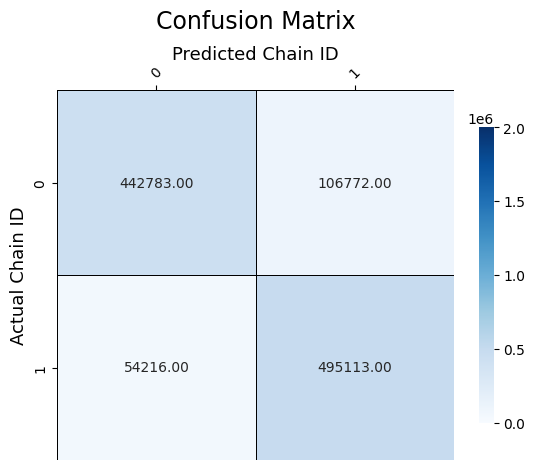

predictive accuracy: 0.8534986404388453

R*: 1.7069972808776905

=====

Testing Results!

train prediction:[0 1 1 ... 0 1 0]

train true:        ID
585168   0
673520   0
342479   1
279906   1
585118   0
...     ..
277894   0
551168   1
797668   0
591251   1
209647   0

[1098884 rows x 1 columns]

[[110452  26796]
 [ 13789 123685]]

2

length of id list:2

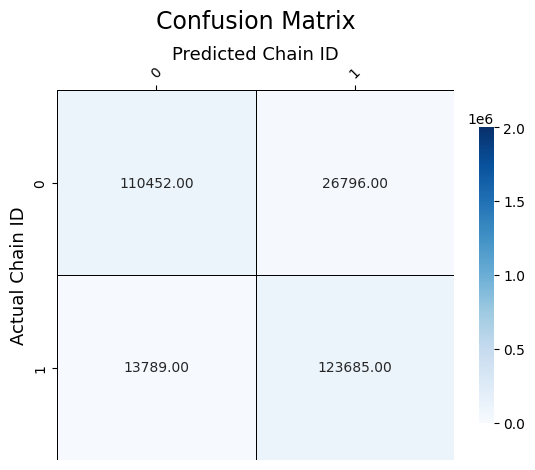

predictive accuracy: 0.8522688390445614

R*: 1.7045376780891228

=====

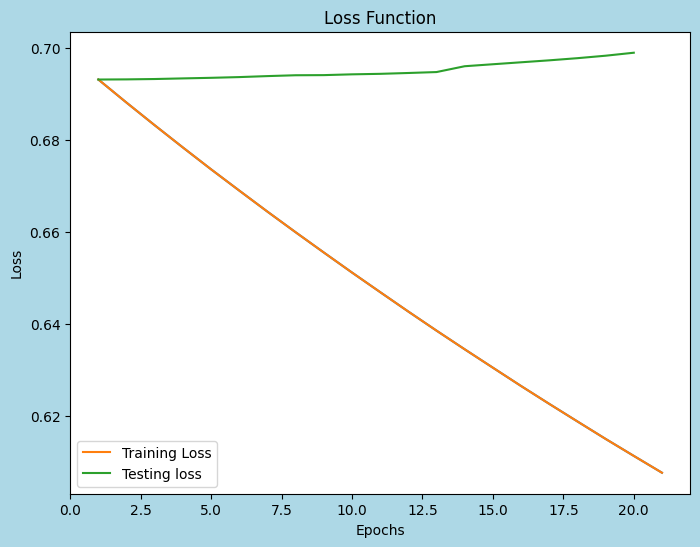

test prediction:[1 1 0 ... 1 1 1]

test true:        ID
291211   0
538152   0
560344   0
487579   0
901212   1
...     ..
351328   1
227902   0
834354   1
295452   1
701928   1

[274722 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

In [36]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_folder= Path("../models/demo_files 2/demo chain 3/")


files=[f"{path_to_folder}/{x}" for x in os.listdir(path_to_folder)] 

print(files)
fitting_label = "ID"
paths = [files]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        # chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5" 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>200000"])
        chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<123456"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()



        if lm == files:
            temp_identical.append(chain_handler)
 

data = temp_identical[0]
data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0


chain = temp_identical[1]
chain.ttree_array['ID']=1

temp = [data, chain]
#print(len(temp_identical[0].ttree_array))
#print(len(temp_identical[1].ttree_array))

lengths = [n.ttree_array.shape[0] for n in temp]
min_len = min(lengths)
data.ttree_array=data.ttree_array[:min_len]

print(len(data.ttree_array))

data.ttree_array = pd.concat([data.ttree_array, chain.ttree_array])

print(len(chain.ttree_array))
print(len(data.ttree_array))


print(data.ttree_array)
# First step we need to initialise the factory
path_to_folder.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
ml_factory_id = MLFactory(data, fitting_label, f"{path_to_folder}.pdf")
ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=20, verbose=2, max_leaf_nodes=500, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_id.set_training_test_set(0.2)

ml_model_id.train_model()
print('=========================')
print(f'results for identical:')
ml_model_id.test_model_class(files, 'adapt', 't2k', norm= False, model=ml_model_id)

### Trace-Hist plots

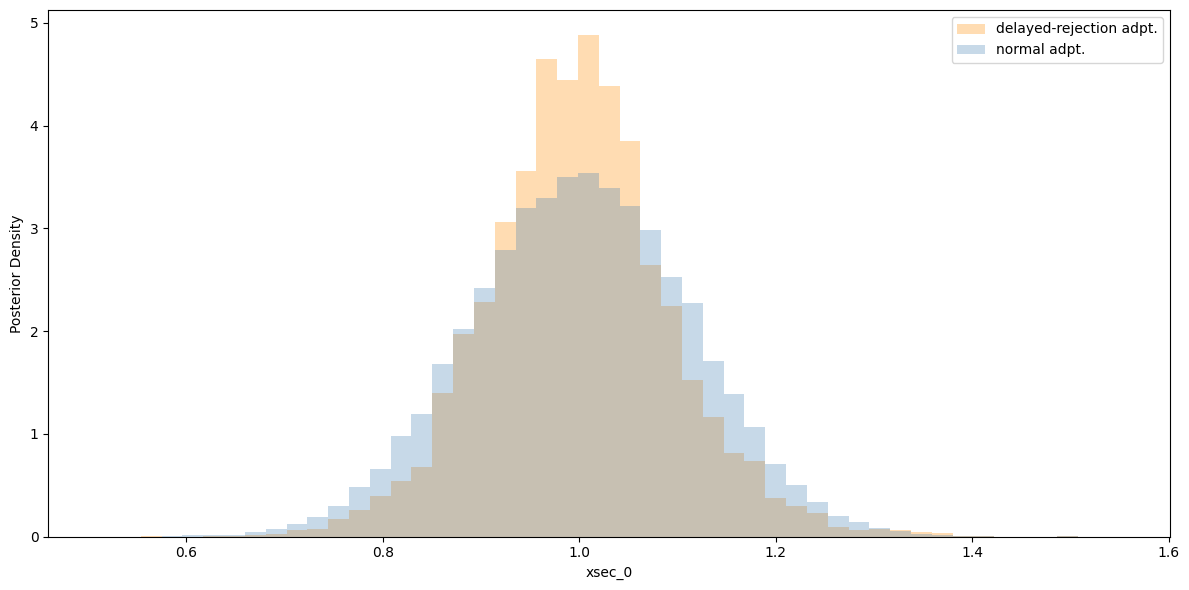

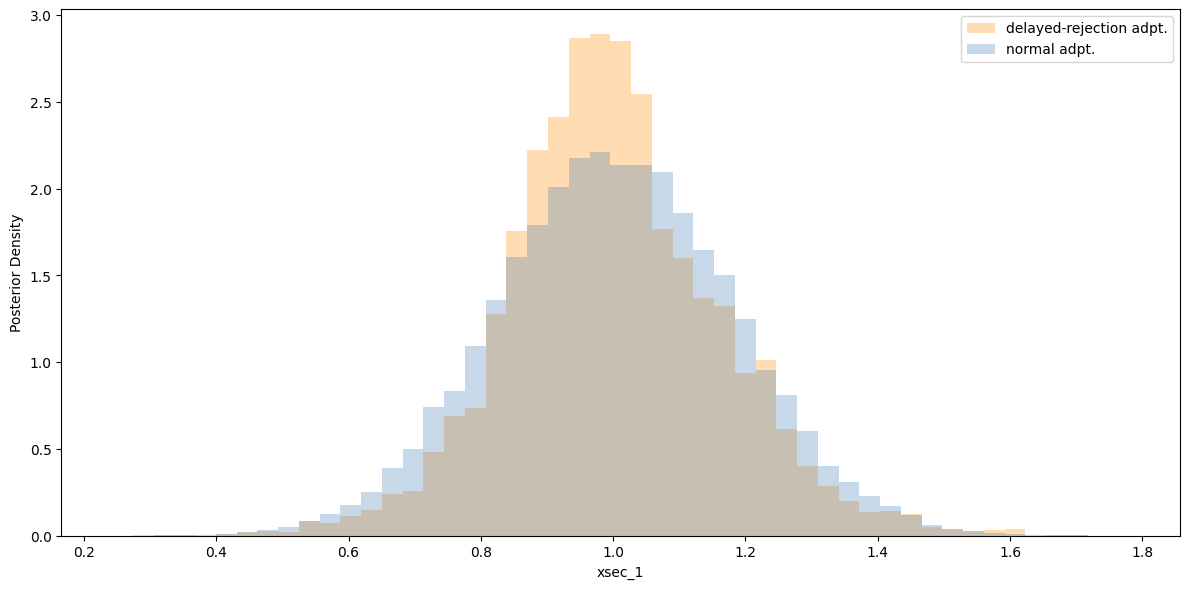

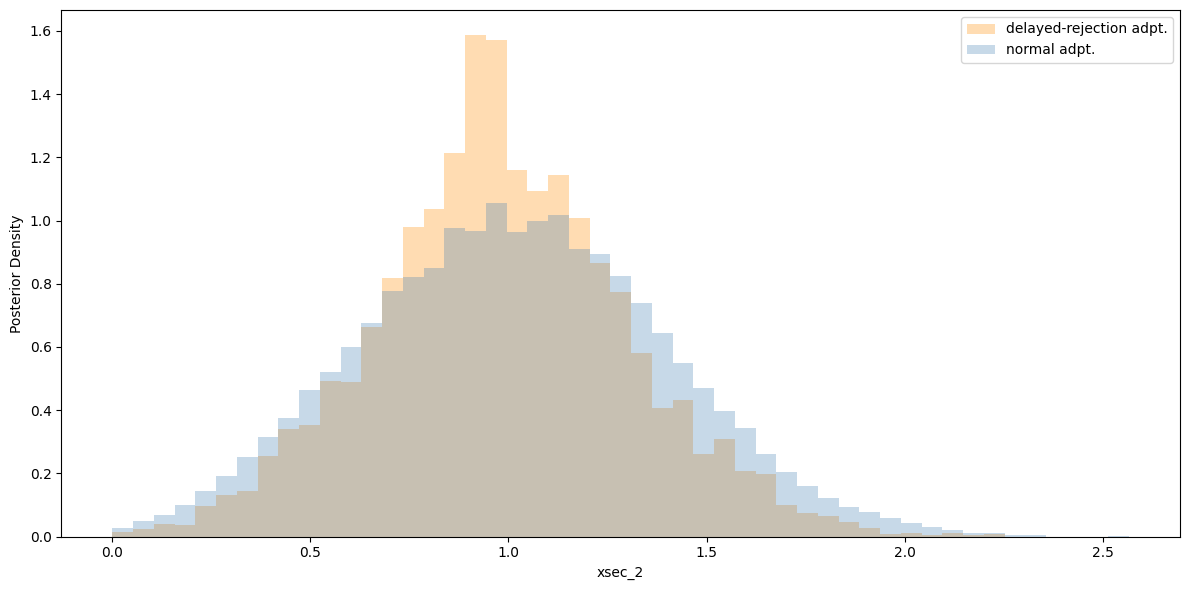

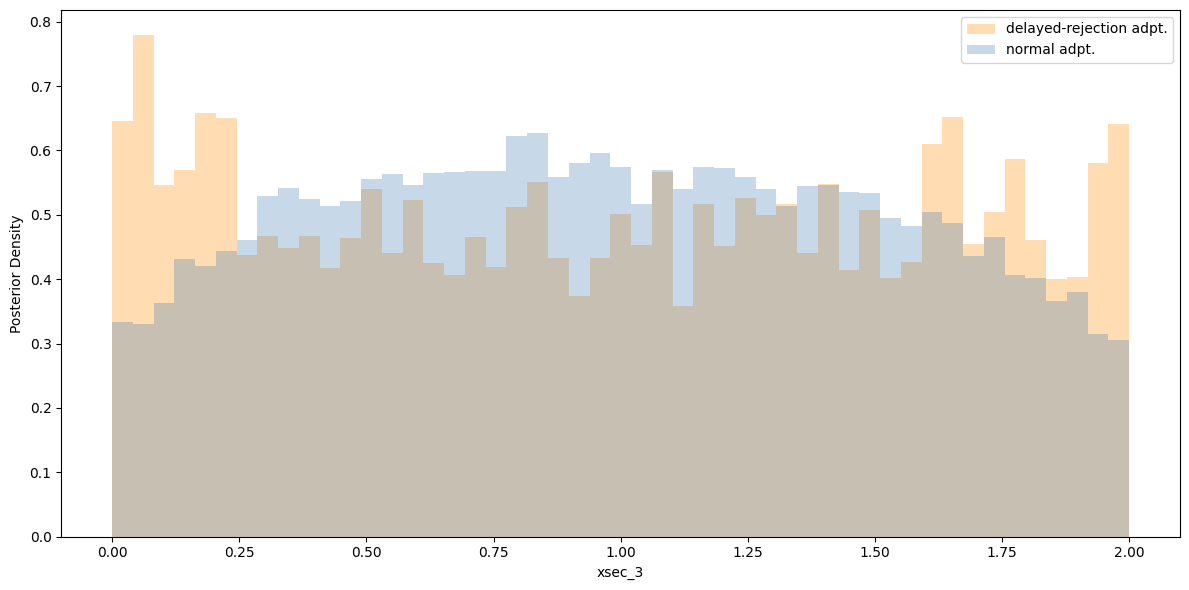

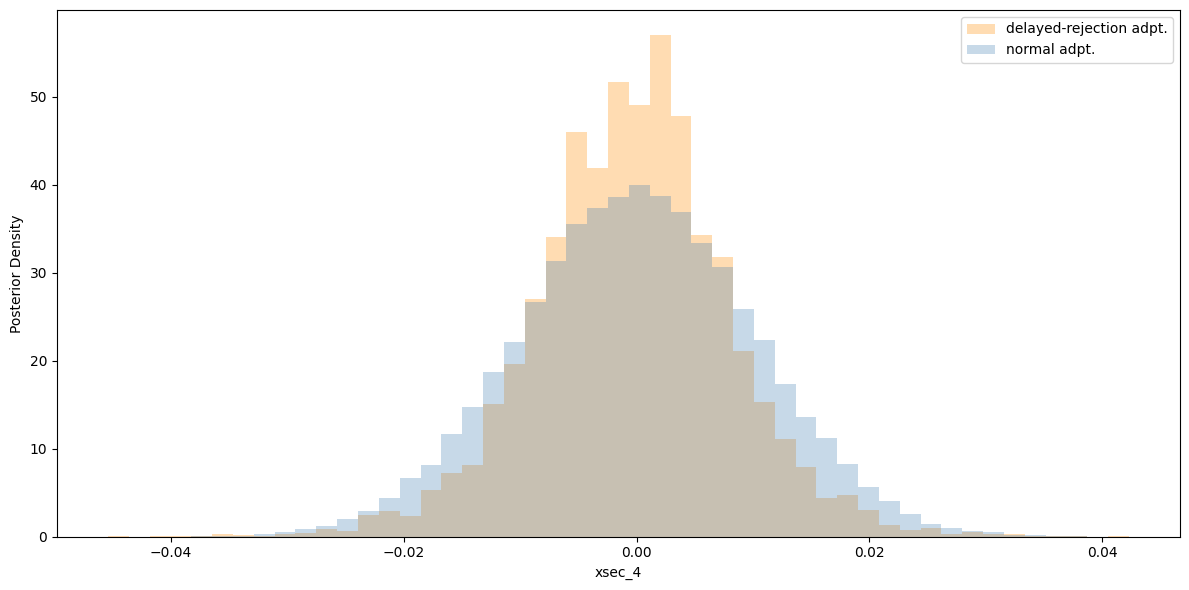

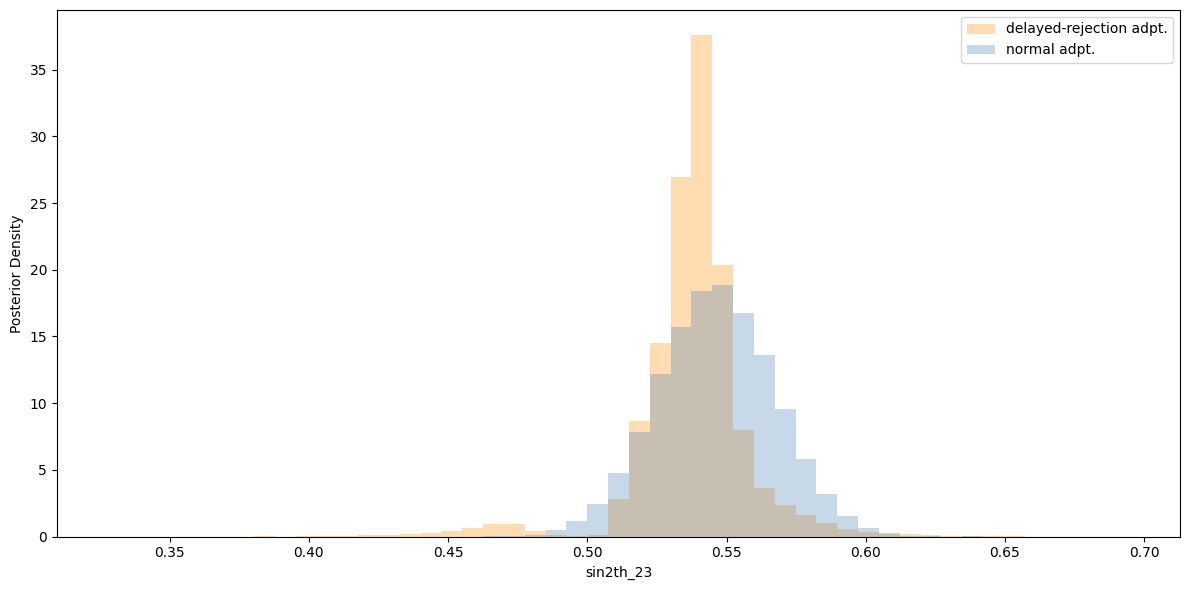

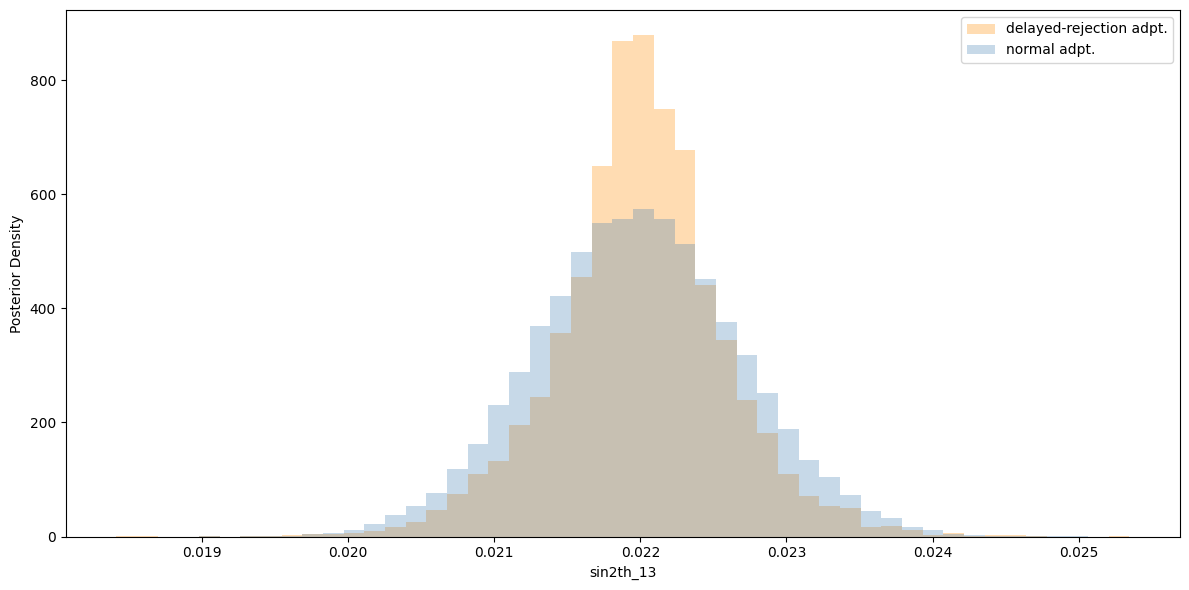

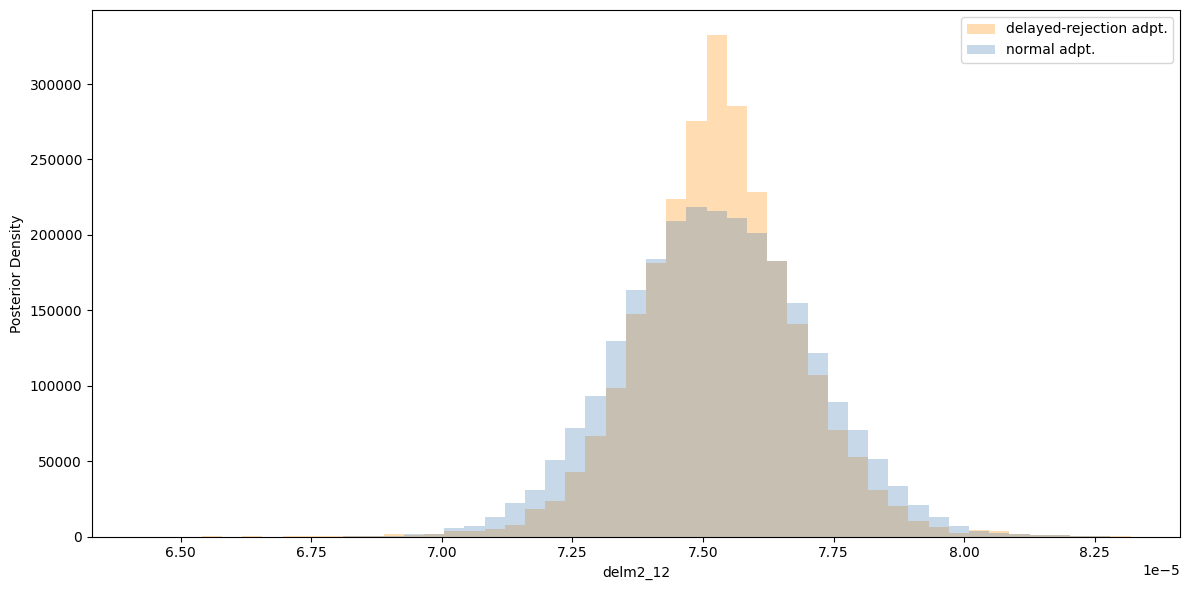

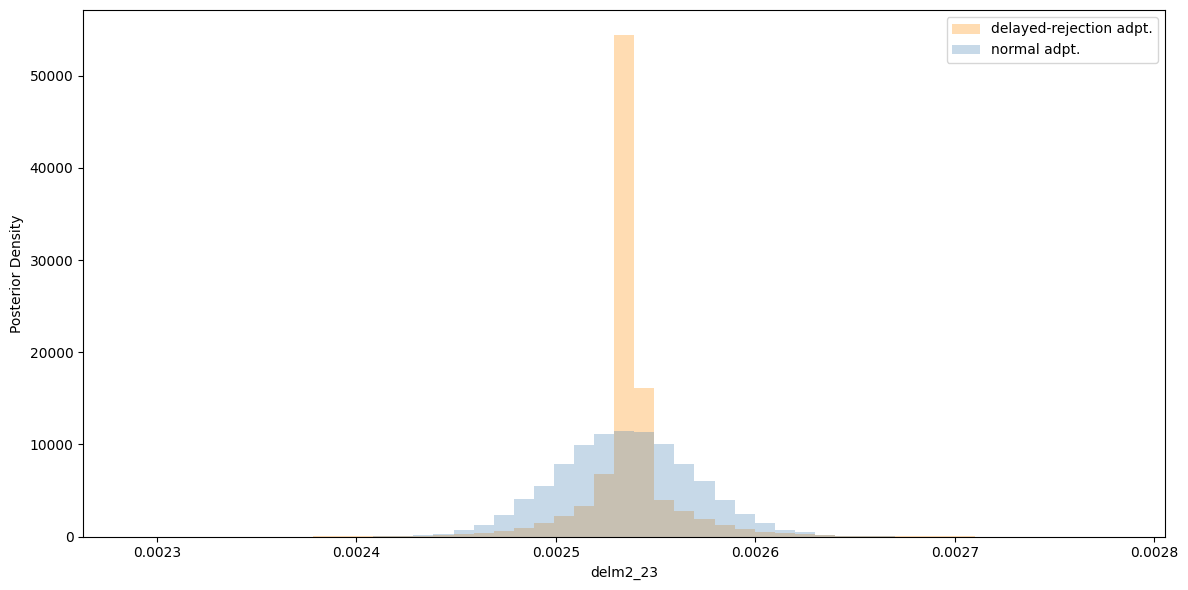

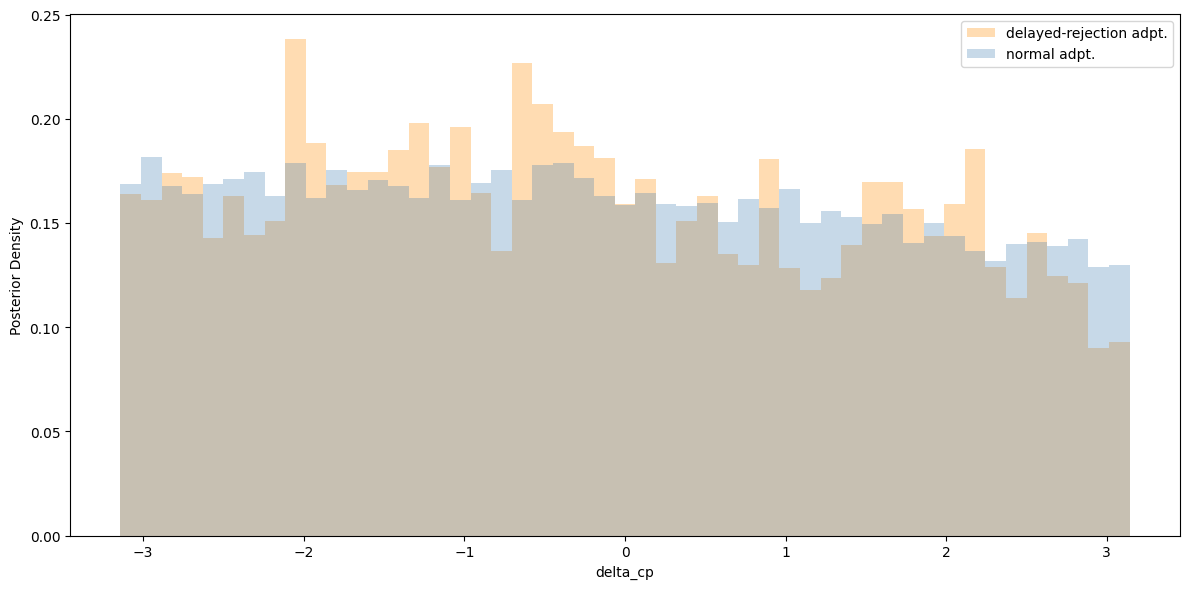

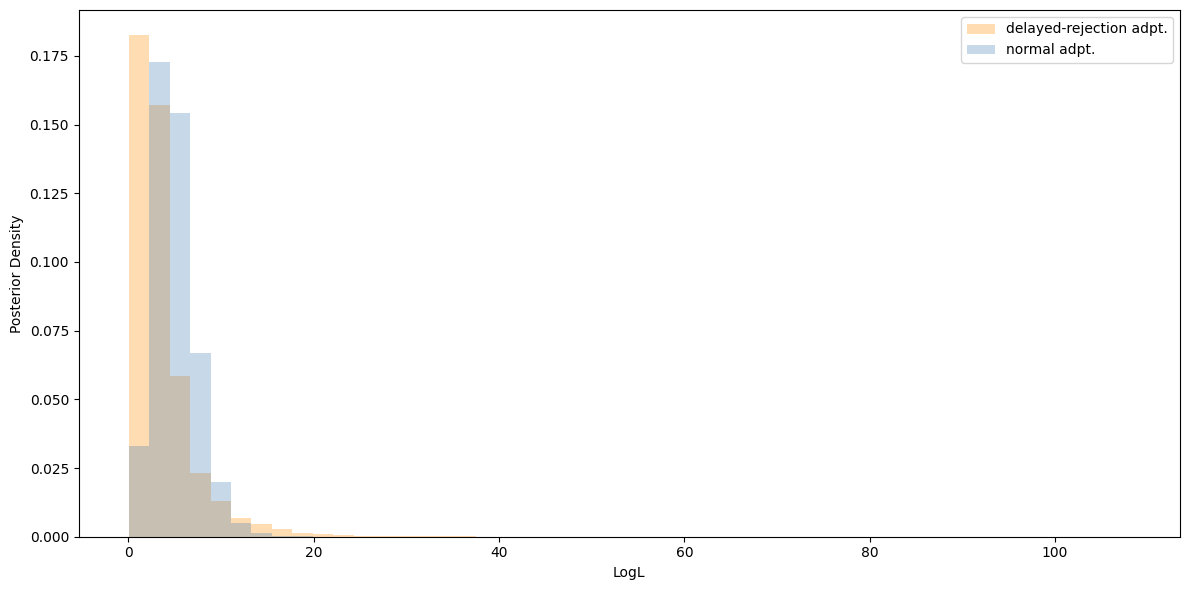

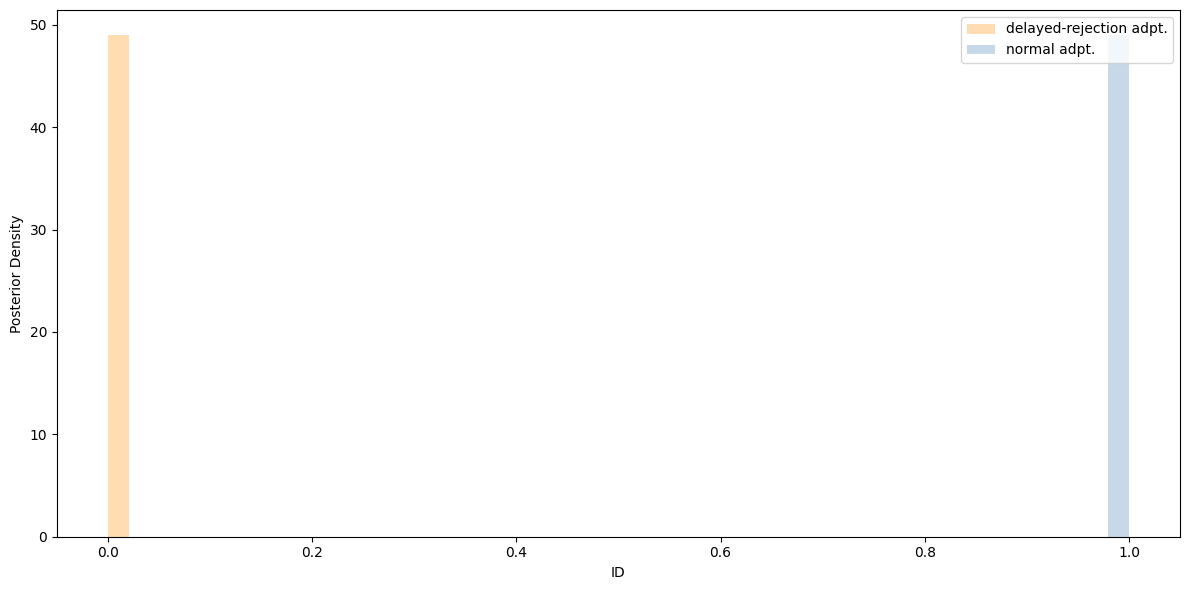

In [26]:
temp[0].ttree_array = temp[0].ttree_array[temp[0].ttree_array["ID"]==0]

for col in temp[0].ttree_array.columns:

    if col not in temp[1].ttree_array.columns:
        raise Exception(f"Error could not find {col}")

    plotter_delayed=ChainDiagnostics(temp[0])
    plotter_mcmc= ChainDiagnostics(temp[1])
    #plotter_delayed("xsec_0")
    #plotter_mcmc("xsec_0")
    #plt.show()

    delayed_chain, paramname = plotter_delayed._extract_chain_information(col)
    mcmc_chain, paramname = plotter_mcmc._extract_chain_information(col)

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))

    # ax[0].plot(delayed_chain, lw=0.5, label='delayed-rejection adpt.', color='darkorange')
    # ax[0].plot(mcmc_chain, lw=0.5, label='normal adpt.', color='steelblue')
    # ax[0].set_xlabel('Iteration')
    # ax[0].set_ylabel('Parameter value')


    bins = np.linspace(min(min(delayed_chain), min(mcmc_chain)), max(max(delayed_chain), max(mcmc_chain)), 50)

    ax.hist(delayed_chain, bins=bins, lw=0.5, label='delayed-rejection adpt.', color='darkorange', density=True, alpha=0.3)
    ax.hist(mcmc_chain, bins=bins, lw=0.5, label='normal adpt.', color='steelblue', density=True, alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_xlabel(col)
    ax.set_ylabel("Posterior Density")

    plt.tight_layout()
    plt.show()



### <ins>Delayed </ins> Correlated Bounded Adaptive versus <ins> Normal </ins> Correlated Bounded Adaptive

I'm getting R* values ~ 1.35, which means that it is actually doing a pretty good job in differentiating it, Rhat defaults to 1.0 and so is less sensitive to smaller differences, but the chains have not converged well, since the shape of the posterior is very choppy and not smooth, gaussian-like.


['../models/demo_files 2/adaptive_correlated/delayed_correlated_bounded_no_osc_flips.root', '../models/demo_files 2/adaptive_correlated/mcmc_correlated_bounded_no_osc_flips.root']
Attempting to open ../models/demo_files 2/adaptive_correlated/delayed_correlated_bounded_no_osc_flips.root
Succesfully opened ../models/demo_files 2/adaptive_correlated/delayed_correlated_bounded_no_osc_flips.root:posteriors
Using 12 threads and requiring 0.392 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_3
  -> xsec_4
  -> xsec_5
  -> xsec_6
  -> xsec_7
  -> xsec_8
  -> xsec_9
  -> sin2th_12
  -> sin2th_23
  -> sin2th_13
  -> delm2_12
  -> delm2_23
  -> delta_cp
  -> LogL
Converted TTree to pandas dataframe with 812673 elements
Attempting to open ../models/demo_files 2/adaptive_correlated/mcmc_correlated_bounded_no_osc_flips.root
Succesfully opened ../models/demo_files 2/adaptive_correlated/mcmc_correlated_bounded_no_osc_flips.root:posteriors
Using 12 threads and req

Number of independent MCMCs: 2

Training Results!

[[356489 191921]
 [162690 386015]]

2

length of id list:2

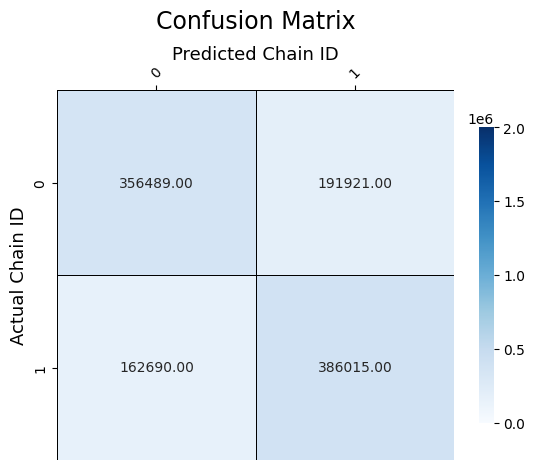

predictive accuracy: 0.6767786421660446

R*: 1.353557284332089

=====

Testing Results!

train prediction:[1 1 1 ... 1 0 0]

train true:         ID
1244414   1
903635    1
406674    1
1564695   0
972275    0
...      ..
988313    0
1020400   1
1720767   1
532258    0
561856    0

[1097115 rows x 1 columns]

[[82912 54375]
 [47176 89816]]

2

length of id list:2

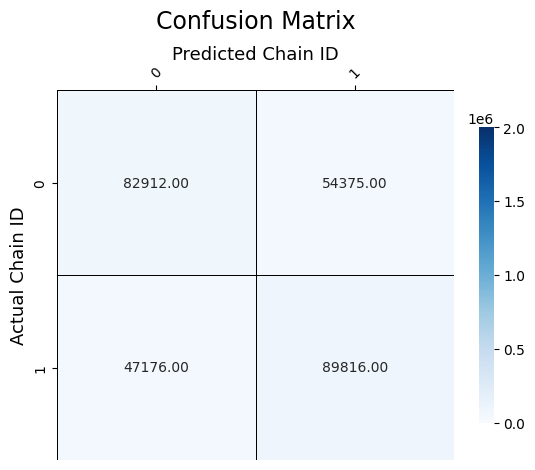

predictive accuracy: 0.6297529158265853

R*: 1.2595058316531706

=====

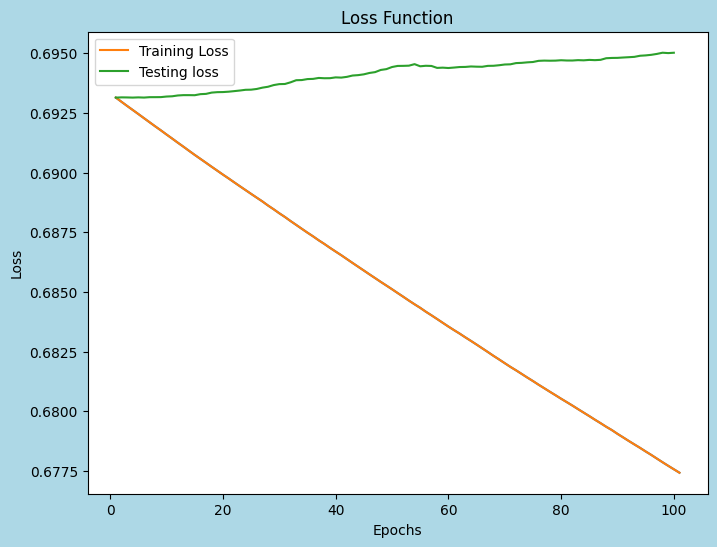

test prediction:[0 0 0 ... 0 1 1]

test true:         ID
1592459   0
272054    0
1610361   0
1128316   1
942680    1
...      ..
980760    0
232195    1
894914    0
702592    0
882396    1

[274279 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

In [3]:
path= Path("../models/demo_files 2/adaptive_correlated/")


link=[f"{path}/{x}" for x in os.listdir(path)] 

print(link)
fitting_label = "ID"
paths = [link]

temp_list=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", 'xsec_6', 'xsec_7', 'xsec_8', 'xsec_9', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>200000", "delm2_23>0"])
        chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<123456"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()

        if lm == link:
            temp_list.append(chain_handler)




delayed_corr= temp_list[0]
delayed_corr.ttree_array['ID']= 0

normal_corr= temp_list[1]
normal_corr.ttree_array['ID']=1

print(f'delayed corr:{len(delayed_corr.ttree_array)}')
print(f'normal corr: {len(normal_corr.ttree_array)}')

temporary_list = [delayed_corr, normal_corr]
#print(len(temp_identical[0].ttree_array))
#print(len(temp_identical[1].ttree_array))

lengths = [n.ttree_array.shape[0] for n in temporary_list]
min_length = min(lengths)
delayed_corr.ttree_array=delayed_corr.ttree_array[:min_length]

print(f'delayed corr after slicing:{len(delayed_corr.ttree_array)}')
print(f'normal corr after slicing : {len(normal_corr.ttree_array)}')

delayed_corr.ttree_array= pd.concat([delayed_corr.ttree_array, normal_corr.ttree_array])

#print(datas.ttree_array)

path.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
ml_factory_delayed = MLFactory(delayed_corr, fitting_label, f"{path}.pdf")
ml_model_delayed = ml_factory_delayed.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=100, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_delayed.set_training_test_set(0.2)

ml_model_delayed.train_model()
print('=========================')
print(f'results for identical:')
ml_model_delayed.test_model_class(link, 'adapt', 't2k', norm= False, model=ml_model_delayed)

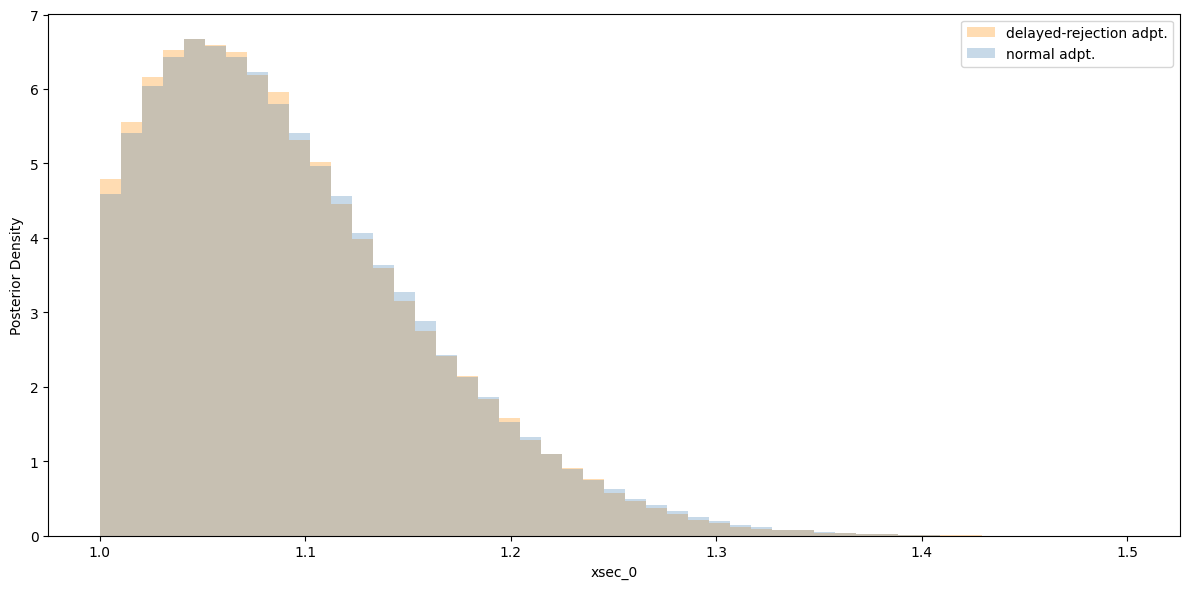

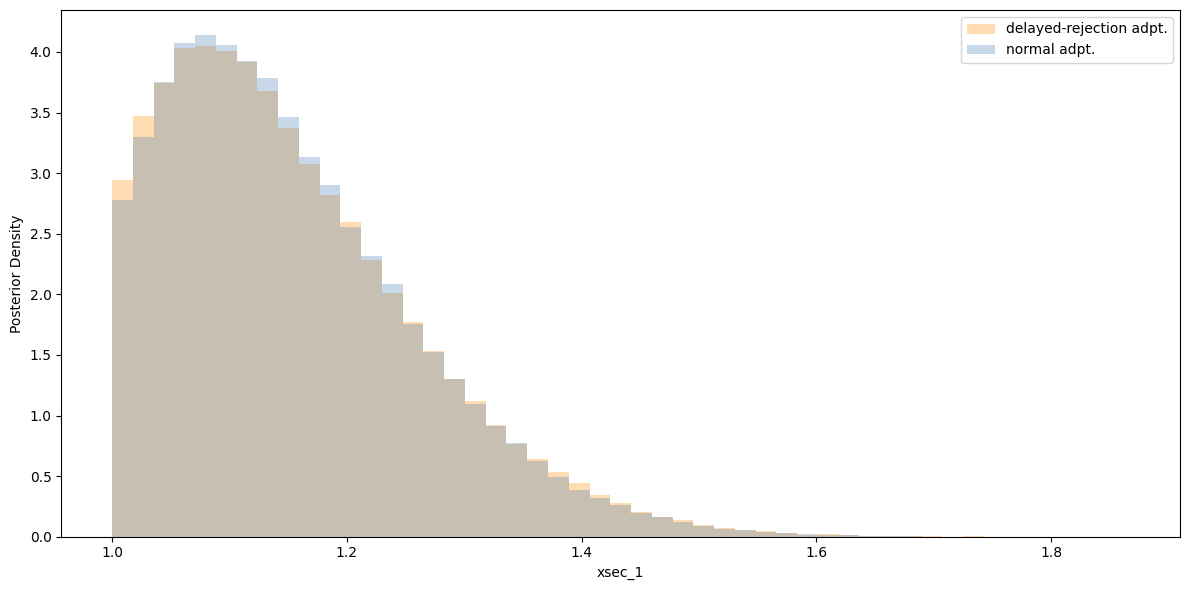

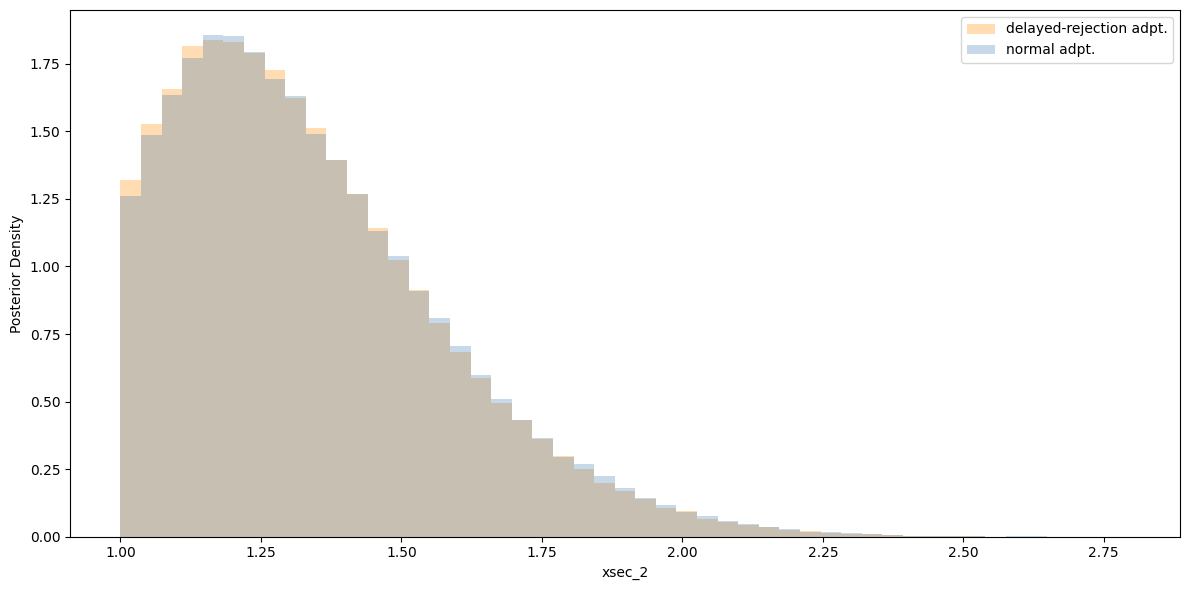

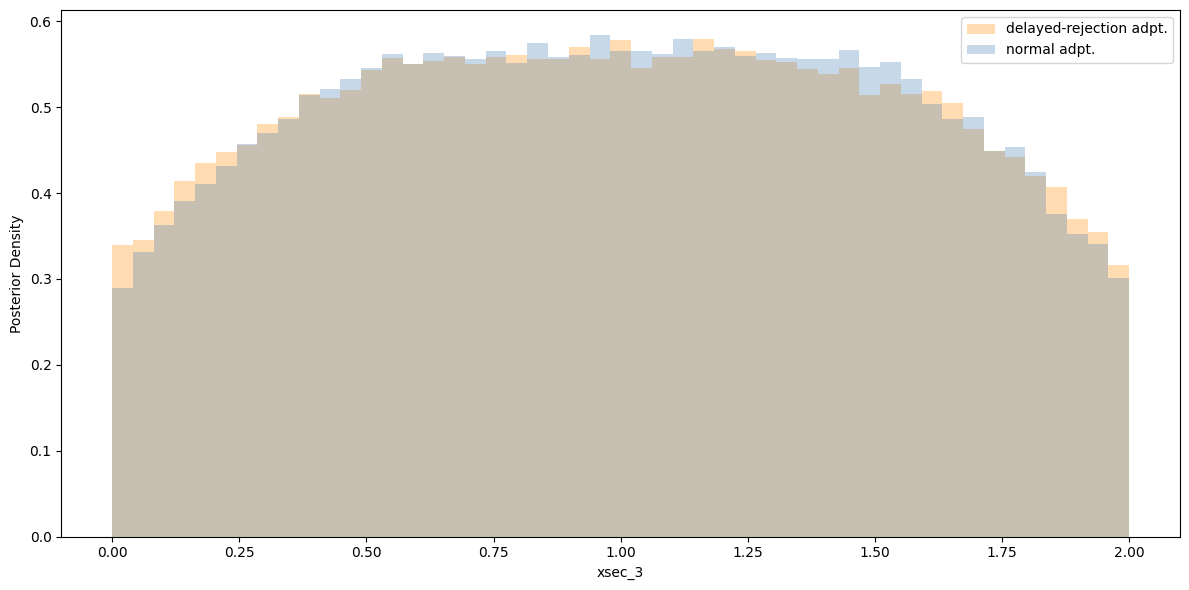

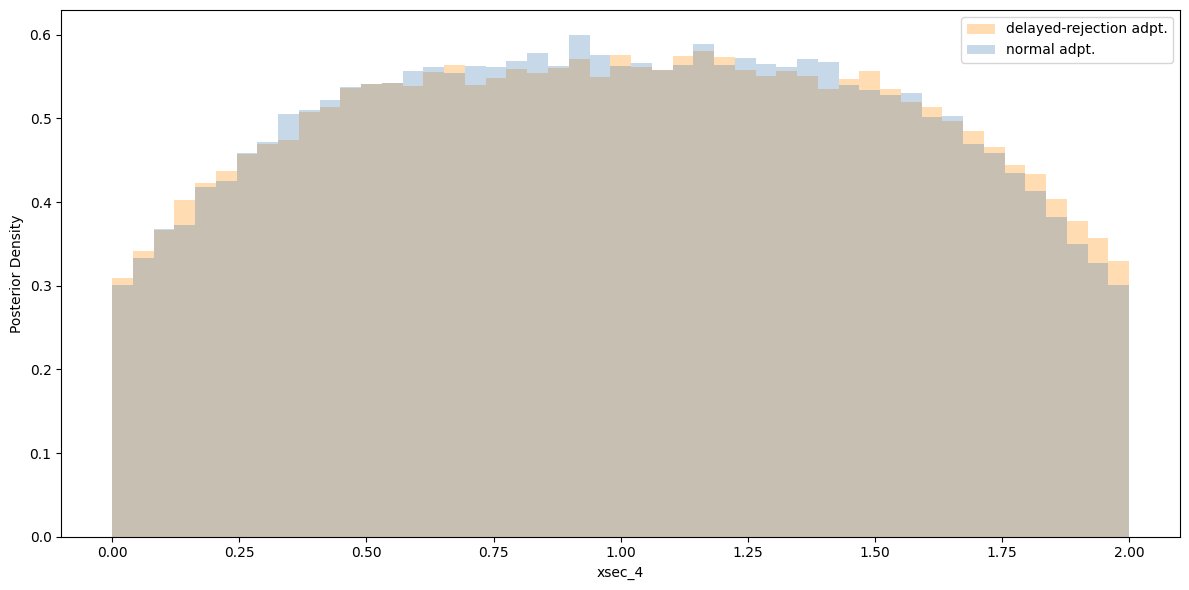

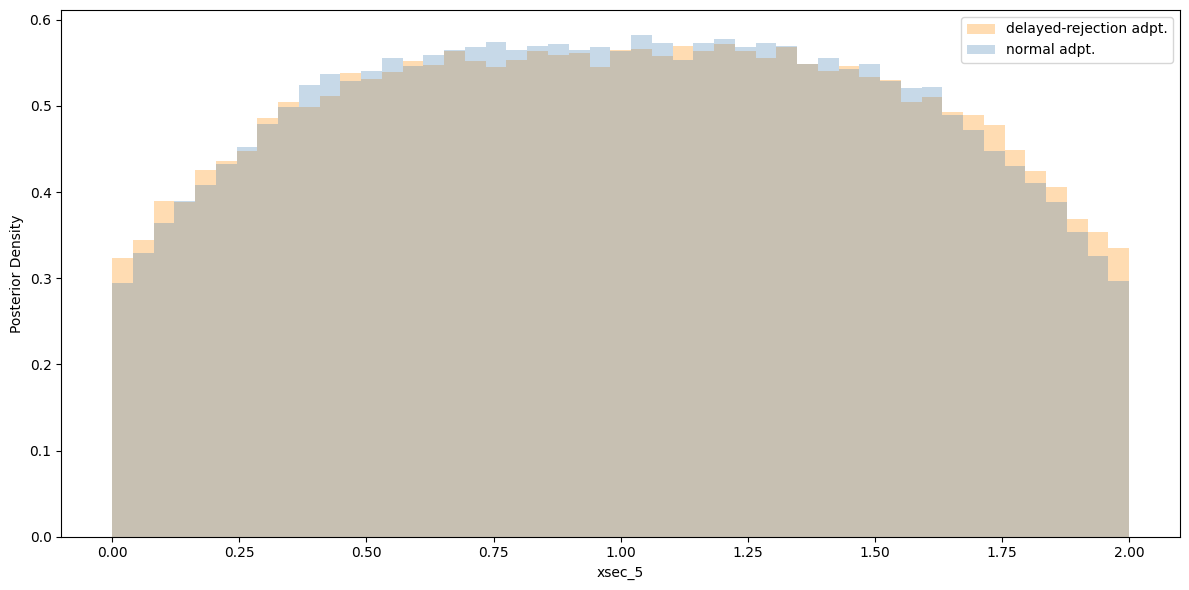

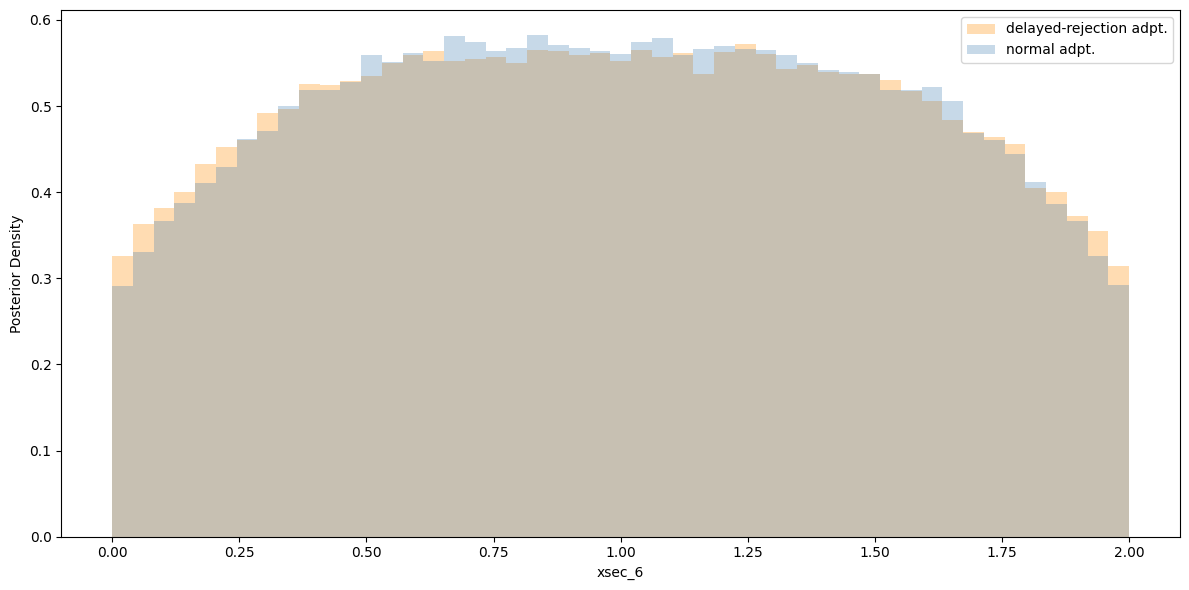

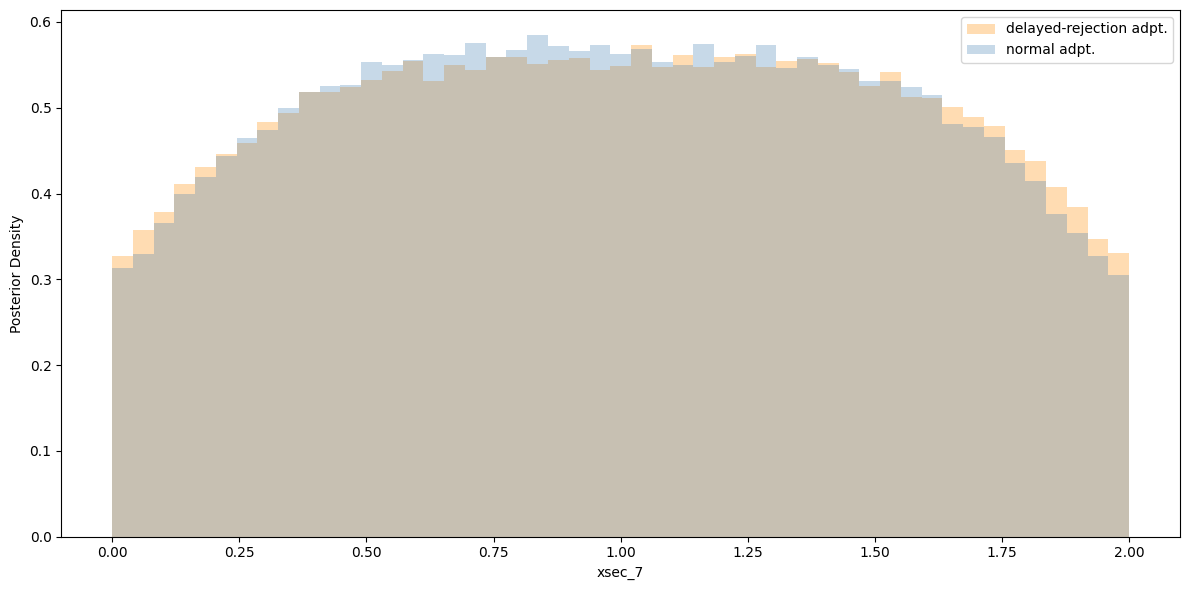

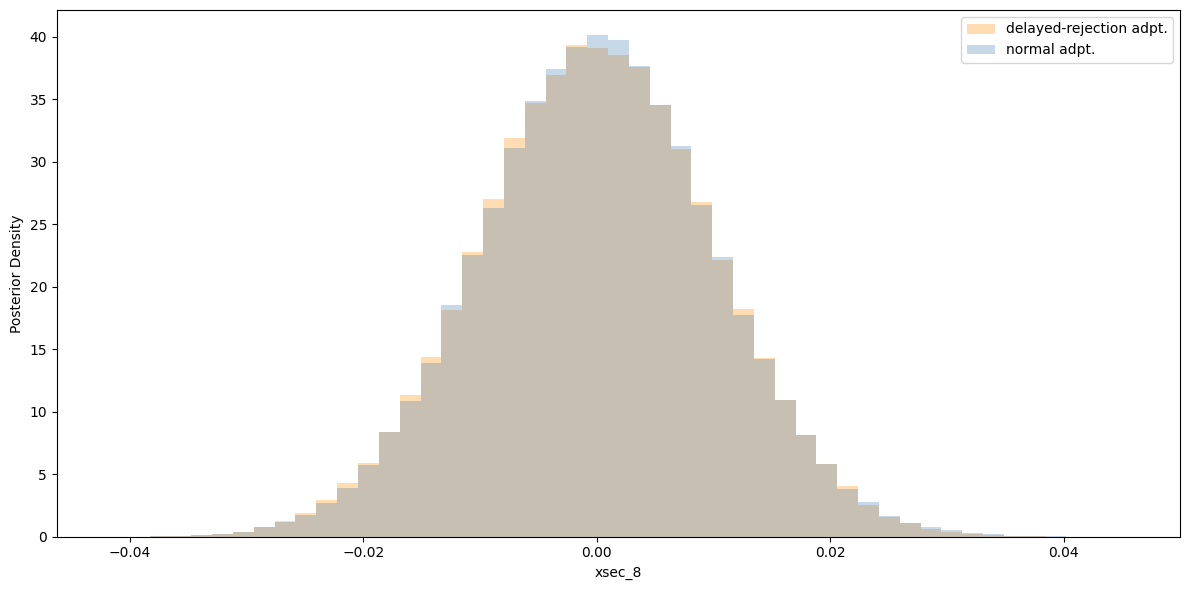

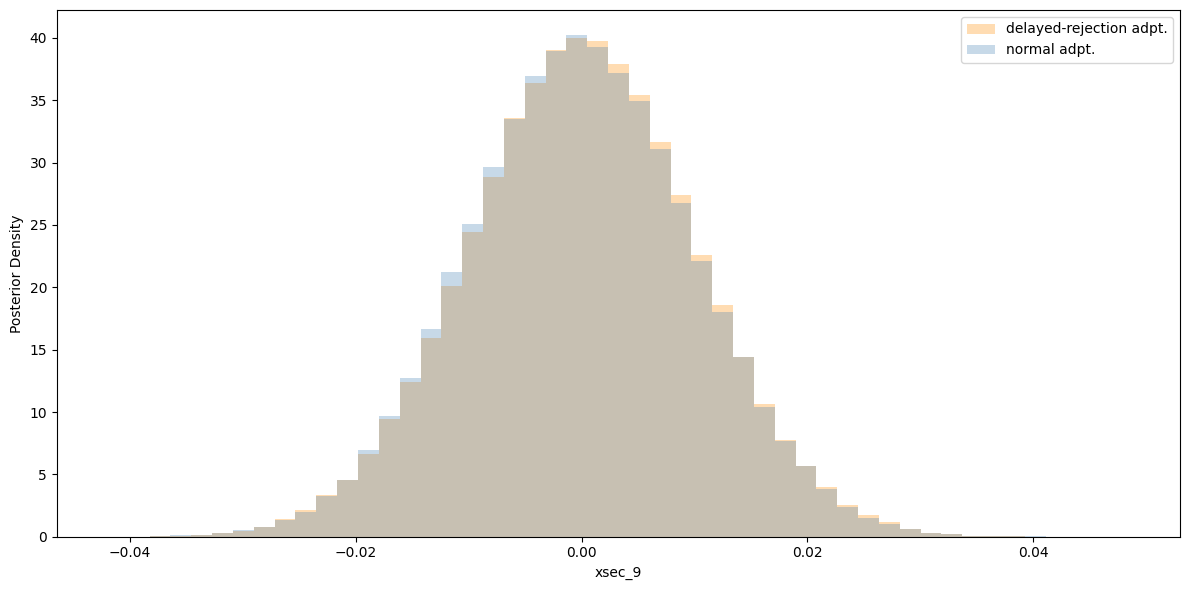

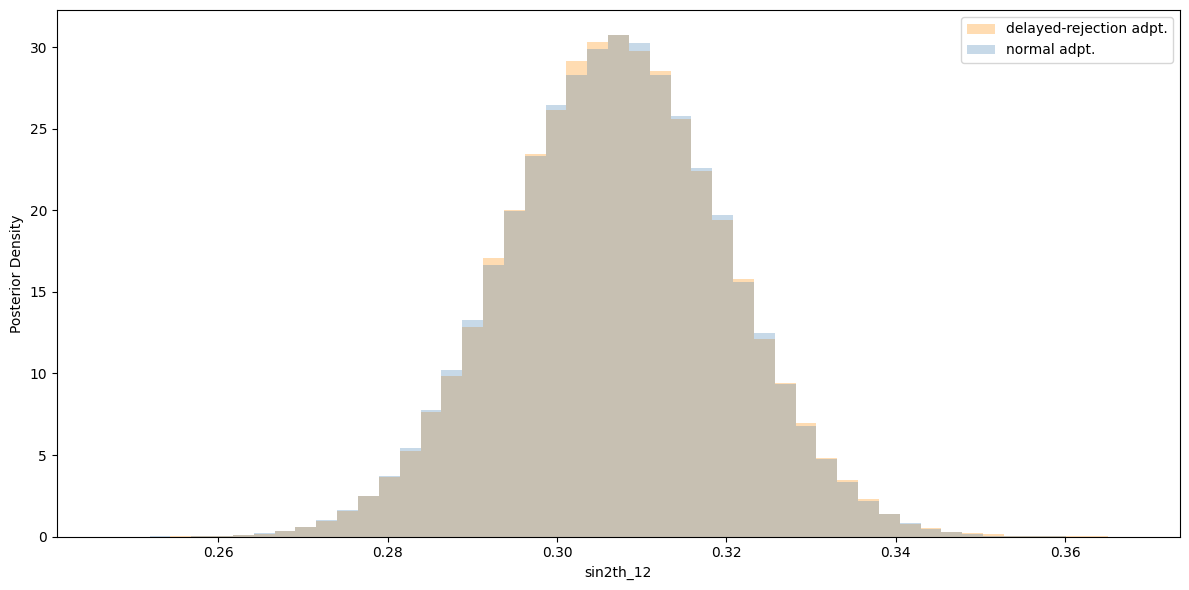

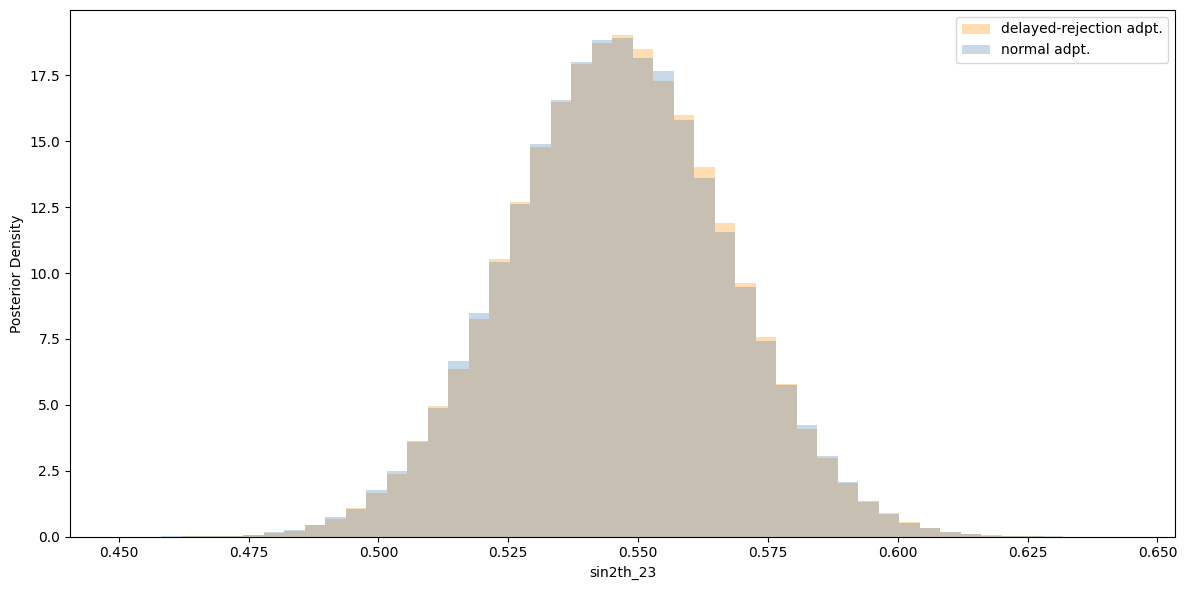

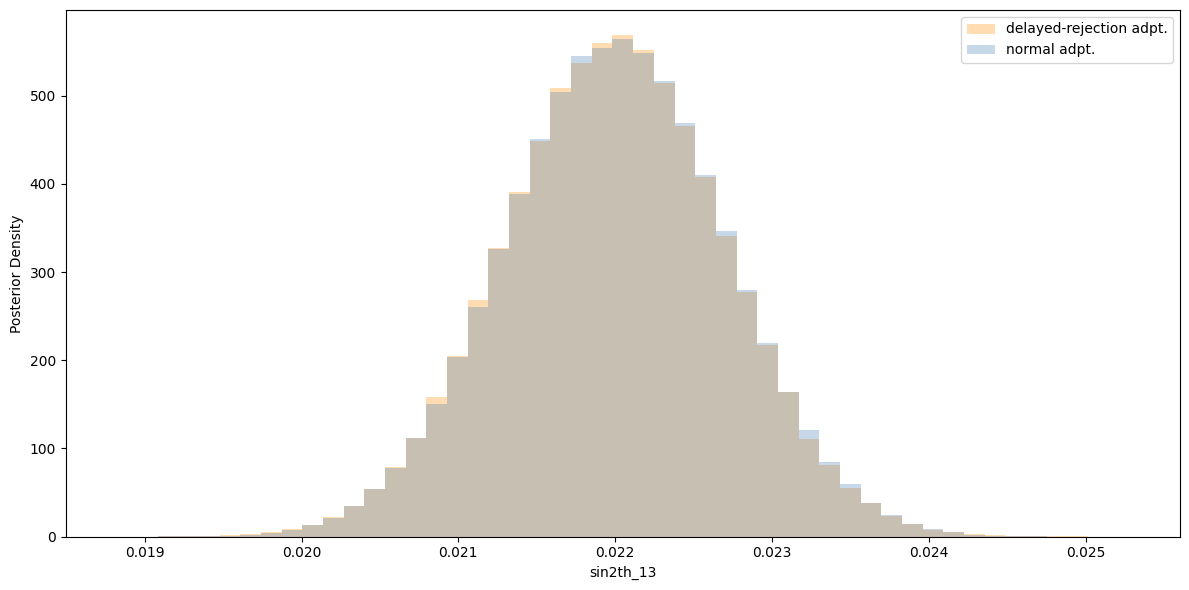

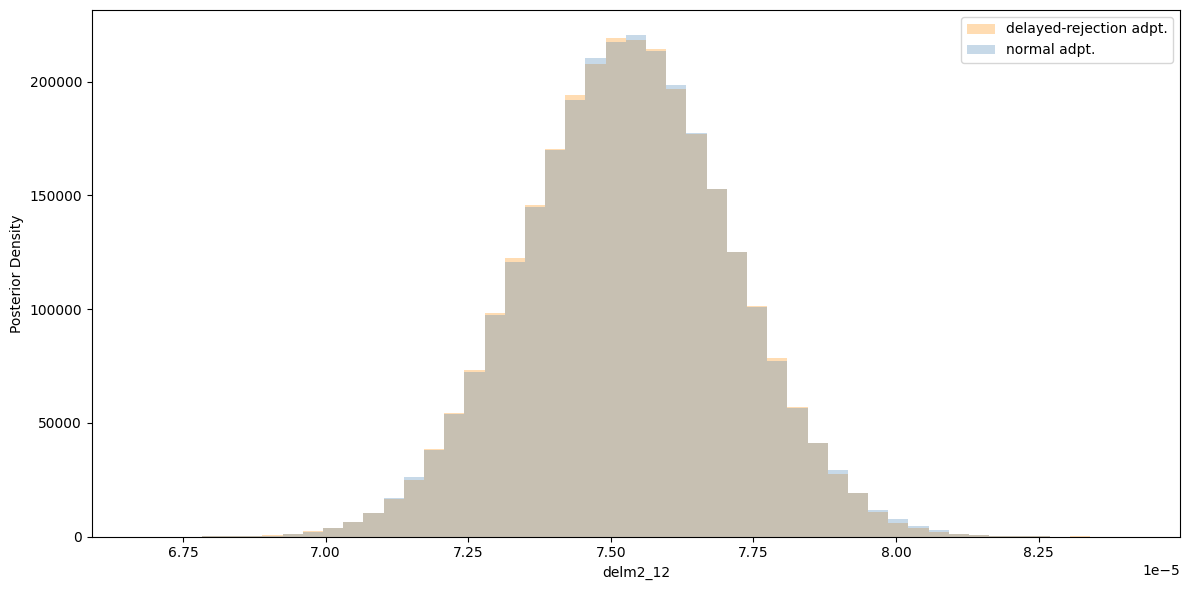

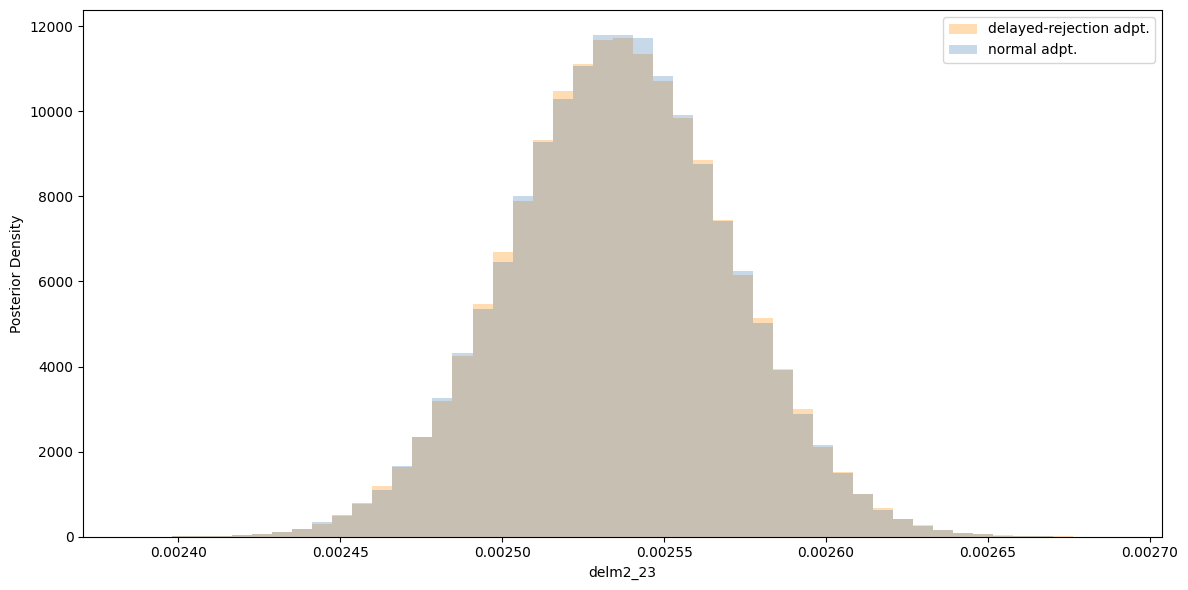

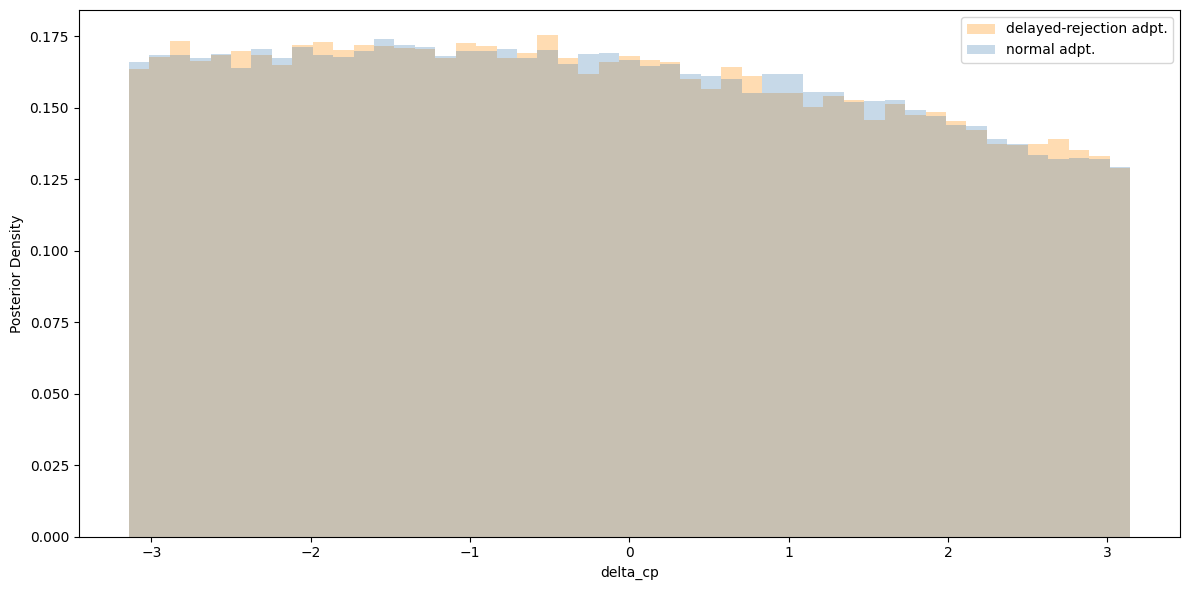

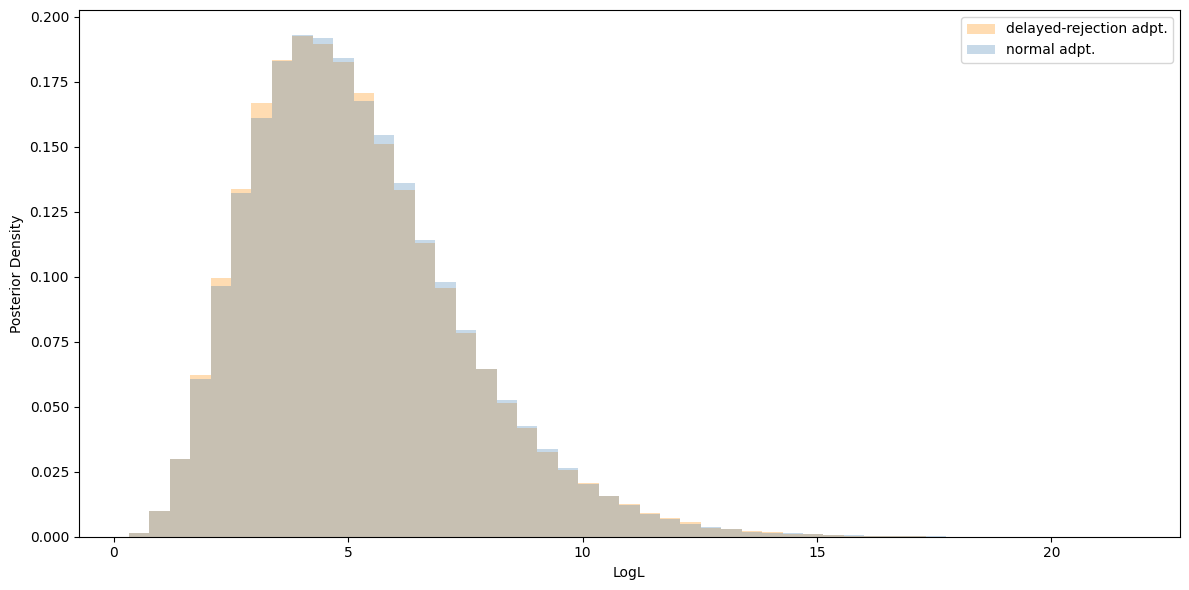

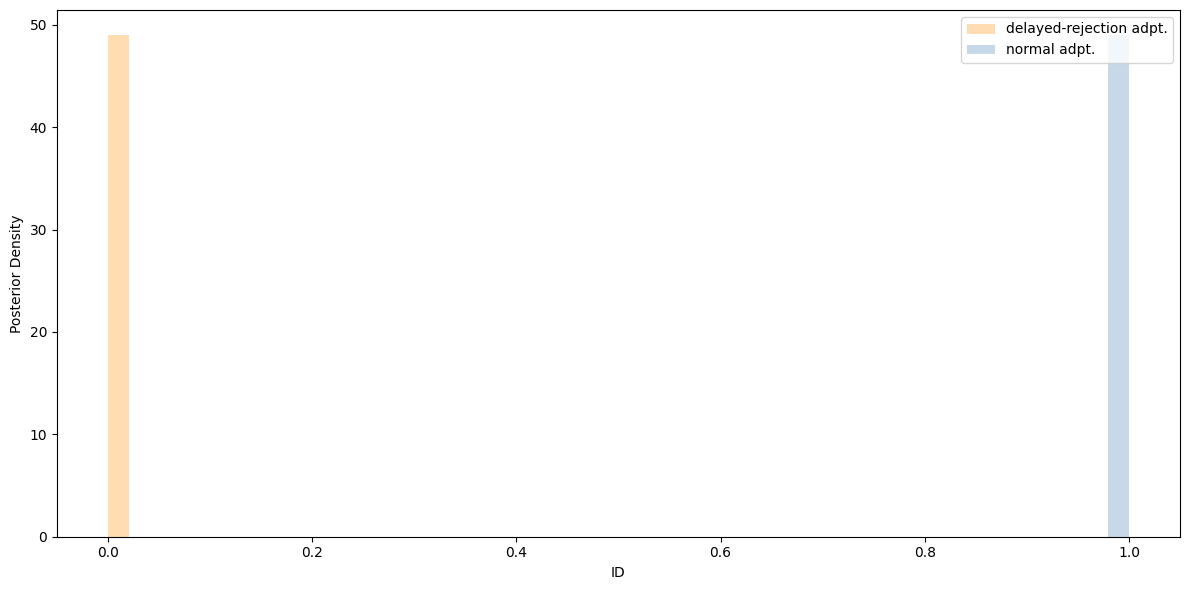

In [ ]:
temp_list[0].ttree_array = temp_list[0].ttree_array[temp_list[0].ttree_array["ID"]==0]

for col in temp_list[0].ttree_array.columns:

    if col not in temp_list[1].ttree_array.columns:
        raise Exception(f"Error could not find {col}")

    plotter_delayed_corr=ChainDiagnostics(temp_list[0])
    plotter_mcmc_corr= ChainDiagnostics(temp_list[1])
    #plotter_delayed("xsec_0")
    #plotter_mcmc("xsec_0")
    #plt.show()

    delayed_corr_chain, paramname = plotter_delayed_corr._extract_chain_information(col)
    mcmc_corr_chain, paramname = plotter_mcmc_corr._extract_chain_information(col)

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))

    # ax[0].plot(delayed_chain, lw=0.5, label='delayed-rejection adpt.', color='darkorange')
    # ax[0].plot(mcmc_chain, lw=0.5, label='normal adpt.', color='steelblue')
    # ax[0].set_xlabel('Iteration')
    # ax[0].set_ylabel('Parameter value')


    bins = np.linspace(min(min(delayed_corr_chain), min(mcmc_corr_chain)), max(max(delayed_corr_chain), max(mcmc_corr_chain)), 50)

    ax.hist(delayed_corr_chain, bins=bins, lw=0.5, label='delayed-rejection adpt.', color='darkorange', density=True, alpha=0.3)
    ax.hist(mcmc_corr_chain, bins=bins, lw=0.5, label='normal adpt.', color='steelblue', density=True, alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_xlabel(col)
    ax.set_ylabel("Posterior Density")

    plt.tight_layout()
    plt.show()

### Identical Chains with increasing iterations; same random noise $10^-{4}$

In [6]:
path_to_chain= Path("../models/demo_files 2/singular_hain/")

identical_chains=[f"{path_to_chain}/{x}" for x in os.listdir(path_to_chain)] 




fitting_label = "ID"
paths = [identical_chains]
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_id_list=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", 'xsec_6', 'xsec_7', 'xsec_8', 'xsec_9', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>200000", "delm2_23>0"])
        chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<123456"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()

        if lm == identical_chains:
            temp_id_list.append(chain_handler)


chain_data = temp_id_list[0]
chain_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

second_chain_data = temp_id_list[1]
second_chain_data.ttree_array['ID']=1
for m in range(10):
    second_chain_data.ttree_array[f'xsec_{m}']= second_chain_data.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(second_chain_data.ttree_array[f'xsec_{m}']))*1e-6)

second_chain_data.ttree_array[f'sin2th_12']= second_chain_data.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(second_chain_data.ttree_array[f'sin2th_12']))*1e-6)
second_chain_data.ttree_array[f'sin2th_23']= second_chain_data.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(second_chain_data.ttree_array[f'sin2th_23']))*1e-6)
second_chain_data.ttree_array[f'sin2th_13']= second_chain_data.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(second_chain_data.ttree_array[f'sin2th_13']))*1e-6)
second_chain_data.ttree_array[f'delm2_12']=second_chain_data.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(second_chain_data.ttree_array[f'delm2_12']))*1e-6)
second_chain_data.ttree_array[f'delm2_23']=second_chain_data.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(second_chain_data.ttree_array[f'delm2_23']))*1e-6)

chain_data.ttree_array=pd.concat([chain_data.ttree_array, second_chain_data.ttree_array])




Attempting to open ../models/demo_files 2/singular_hain/delayed_correlated_bounded_no_osc_flips copy.root
Succesfully opened ../models/demo_files 2/singular_hain/delayed_correlated_bounded_no_osc_flips copy.root:posteriors
Using 12 threads and requiring 0.392 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_3
  -> xsec_4
  -> xsec_5
  -> xsec_6
  -> xsec_7
  -> xsec_8
  -> xsec_9
  -> sin2th_12
  -> sin2th_23
  -> sin2th_13
  -> delm2_12
  -> delm2_23
  -> delta_cp
  -> LogL
Converted TTree to pandas dataframe with 812673 elements
Attempting to open ../models/demo_files 2/singular_hain/delayed_correlated_bounded_no_osc_flips.root
Succesfully opened ../models/demo_files 2/singular_hain/delayed_correlated_bounded_no_osc_flips.root:posteriors
Using 12 threads and requiring 0.392 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_3
  -> xsec_4
  -> xsec_5
  -> xsec_6
  -> xsec_7
  -> xsec_8
  -> xsec_9
  -> sin2th_12

In [7]:

# First step we need to initialise the factory
path_to_chain.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_delayed_corr_10 = MLFactory(chain_data, fitting_label, f"{path_to_chain}.pdf")
ml_factory_delayed_corr_100 = MLFactory(chain_data, fitting_label, f"{path_to_chain}.pdf")
ml_factory_delayed_corr_1k = MLFactory(chain_data, fitting_label, f"{path_to_chain}.pdf")
ml_factory_delayed_corr_10k = MLFactory(chain_data, fitting_label, f"{path_to_chain}.pdf")



ID


Training Model
Binning 0.159 GB of training data: 0.263 s
Binning 0.018 GB of validation data: 0.020 s
Fitting gradient boosted rounds:
[1/10] 1 tree, 550 leaves, max depth = 22, train loss: 0.69304, val loss: 0.69308, in 0.238s
[2/10] 1 tree, 550 leaves, max depth = 23, train loss: 0.69294, val loss: 0.69301, in 0.305s
[3/10] 1 tree, 550 leaves, max depth = 23, train loss: 0.69284, val loss: 0.69294, in 0.211s
[4/10] 1 tree, 550 leaves, max depth = 21, train loss: 0.69274, val loss: 0.69288, in 0.167s
[5/10] 1 tree, 550 leaves, max depth = 24, train loss: 0.69264, val loss: 0.69281, in 0.174s
[6/10] 1 tree, 550 leaves, max depth = 23, train loss: 0.69254, val loss: 0.69275, in 0.170s
[7/10] 1 tree, 550 leaves, max depth = 26, train loss: 0.69244, val loss: 0.69268, in 0.222s
[8/10] 1 tree, 550 leaves, max depth = 22, train loss: 0.69234, val loss: 0.69262, in 0.239s
[9/10] 1 tree, 550 leaves, max depth = 28, train loss: 0.69225, val loss: 0.69256, in 0.218s
[10/10] 1 tree, 550 leaves,

Number of independent MCMCs: 2

Training Results!

[[560729  89570]
 [520688 129289]]

2

length of id list:2

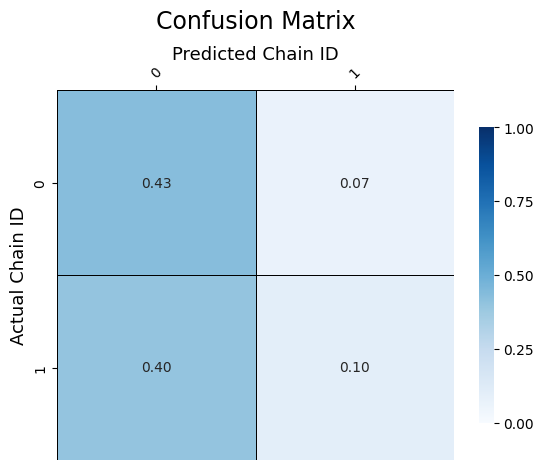

predictive accuracy: 0.5306704115126327

R*: 1.0613408230252654

=====

Testing Results!

train prediction:[0 0 1 ... 0 0 0]

train true:         ID
578080    0
1077897   1
634740    1
1209994   0
310057    0
...      ..
1843748   0
262714    1
1381259   1
632608    0
1683527   0

[1300276 rows x 1 columns]

[[137754  24620]
 [131941  30755]]

2

length of id list:2

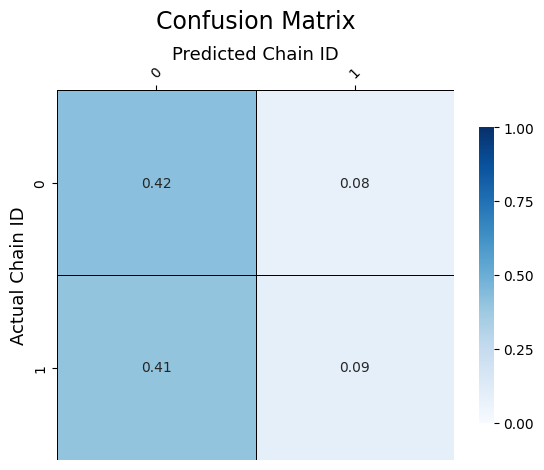

predictive accuracy: 0.5183775802134925

R*: 1.036755160426985

=====

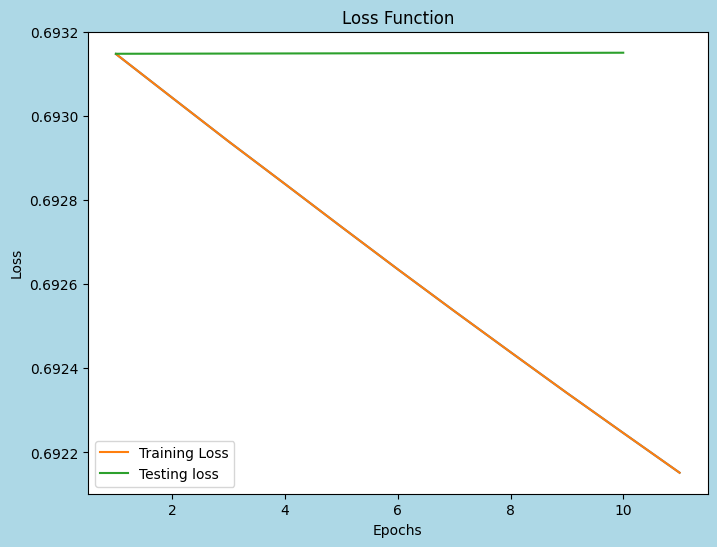

test prediction:[0 0 0 ... 1 0 0]

test true:         ID
1410027   1
814372    1
1978405   1
269729    0
1189206   0
...      ..
1303717   1
468163    1
997085    1
665930    0
1445728   0

[325070 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

Training Model
Binning 0.159 GB of training data: 0.227 s
Binning 0.018 GB of validation data: 0.019 s
Fitting gradient boosted rounds:
[1/100] 1 tree, 550 leaves, max depth = 26, train loss: 0.69304, val loss: 0.69308, in 0.158s
[2/100] 1 tree, 550 leaves, max depth = 26, train loss: 0.69294, val loss: 0.69302, in 0.155s
[3/100] 1 tree, 550 leaves, max depth = 24, train loss: 0.69285, val loss: 0.69296, in 0.146s
[4/100] 1 tree, 550 leaves, max depth = 25, train loss: 0.69275, val loss: 0.69290, in 0.151s
[5/100] 1 tree, 550 leaves, max depth = 26, train loss: 0.69265, val loss: 0.69284, in 0.150s
[6/100] 1 tree, 550 leaves, max depth = 24, train loss: 0.69256, val loss: 0.69278, in 0.151s
[7/100] 1 tree, 550 leaves, max depth = 26, train loss: 0.69246, val loss: 0.69272, in 0.159s
[8/100] 1 tree, 550 leaves, max depth = 25, train loss: 0.69237, val loss: 0.69267, in 0.180s
[9/100] 1 tree, 550 leaves, max depth = 25, train loss: 0.69228, val loss: 0.69261, in 0.197s
[10/100] 1 tree, 5

Number of independent MCMCs: 2

Training Results!

[[571256  79378]
 [498063 151579]]

2

length of id list:2

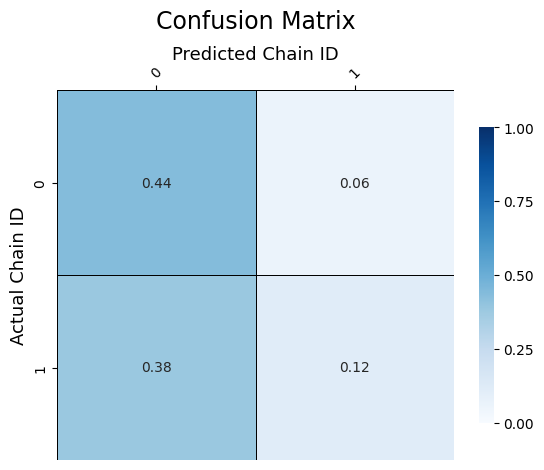

predictive accuracy: 0.5559088993413706

R*: 1.111817798682741

=====

Testing Results!

train prediction:[0 0 0 ... 0 0 0]

train true:         ID
407783    1
974315    1
1079724   0
734633    1
886000    1
...      ..
1635278   0
391009    0
736089    1
1101523   0
1993362   0

[1300276 rows x 1 columns]

[[137820  24219]
 [128881  34150]]

2

length of id list:2

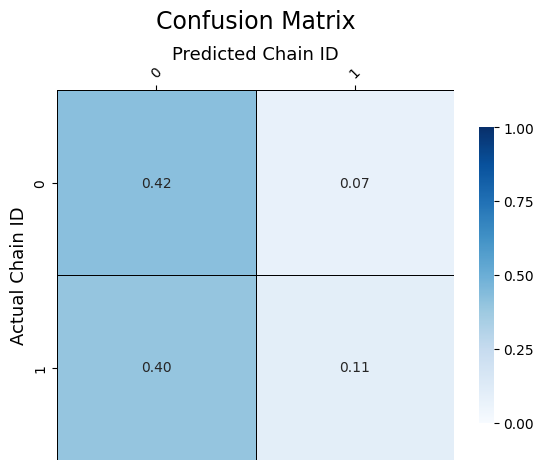

predictive accuracy: 0.529024517796167

R*: 1.058049035592334

=====

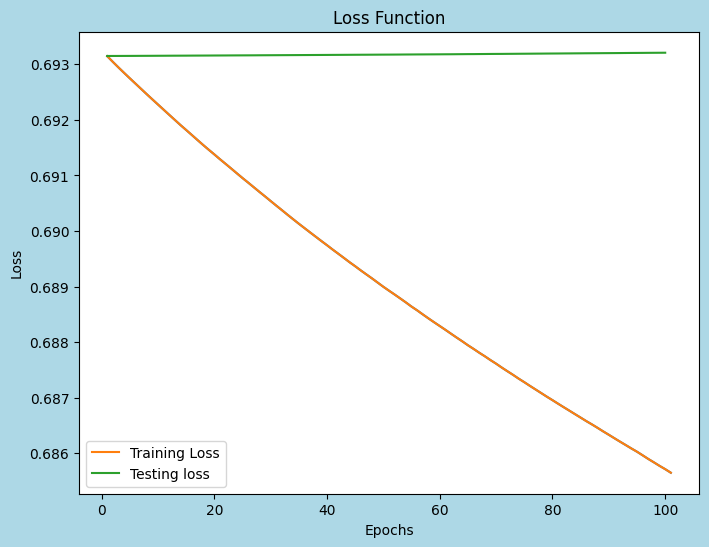

test prediction:[0 0 0 ... 0 0 0]

test true:         ID
578965    1
986914    1
1869526   1
1052797   1
1325605   0
...      ..
1375420   1
1703264   0
1810675   0
1750182   0
1925997   0

[325070 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

Training Model
Binning 0.159 GB of training data: 0.234 s
Binning 0.018 GB of validation data: 0.020 s
Fitting gradient boosted rounds:
[1/1000] 1 tree, 550 leaves, max depth = 24, train loss: 0.69304, val loss: 0.69308, in 0.183s
[2/1000] 1 tree, 550 leaves, max depth = 24, train loss: 0.69294, val loss: 0.69301, in 0.168s
[3/1000] 1 tree, 550 leaves, max depth = 20, train loss: 0.69284, val loss: 0.69294, in 0.212s
[4/1000] 1 tree, 550 leaves, max depth = 21, train loss: 0.69274, val loss: 0.69288, in 0.213s
[5/1000] 1 tree, 550 leaves, max depth = 23, train loss: 0.69264, val loss: 0.69282, in 0.185s
[6/1000] 1 tree, 550 leaves, max depth = 23, train loss: 0.69254, val loss: 0.69276, in 0.194s
[7/1000] 1 tree, 550 leaves, max depth = 23, train loss: 0.69244, val loss: 0.69270, in 0.176s
[8/1000] 1 tree, 550 leaves, max depth = 28, train loss: 0.69234, val loss: 0.69264, in 0.210s
[9/1000] 1 tree, 550 leaves, max depth = 23, train loss: 0.69225, val loss: 0.69257, in 0.215s
[10/1000]

Number of independent MCMCs: 2

Training Results!

[[575512  74128]
 [287284 363352]]

2

length of id list:2

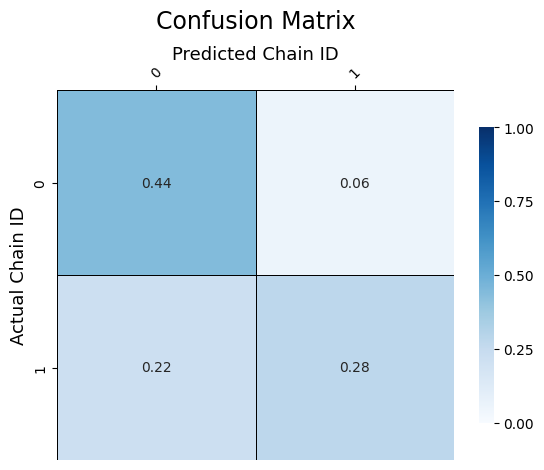

predictive accuracy: 0.7220497802005112

R*: 1.4440995604010225

=====

Testing Results!

train prediction:[0 0 0 ... 1 1 0]

train true:         ID
712161    0
1130486   0
249418    0
1027652   0
1730406   1
...      ..
821631    0
1737907   1
366656    1
485358    1
1287249   0

[1300276 rows x 1 columns]

[[124391  38642]
 [ 95073  66964]]

2

length of id list:2

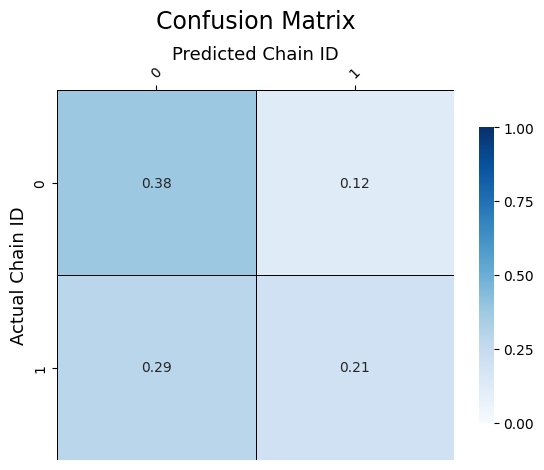

predictive accuracy: 0.5886578275448365

R*: 1.177315655089673

=====

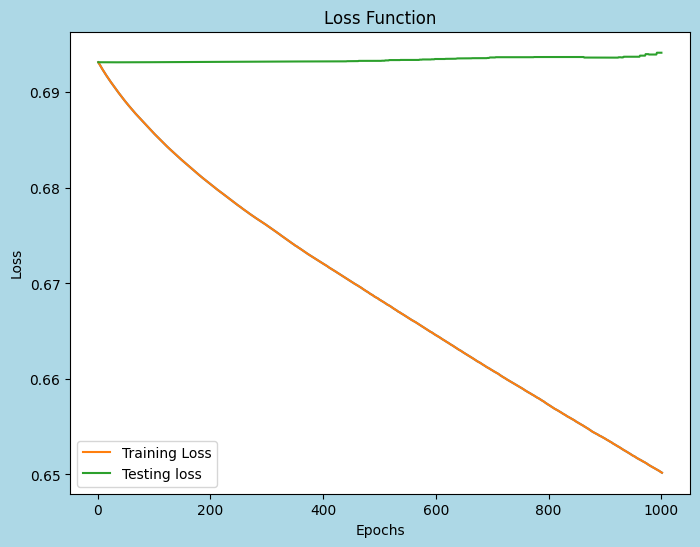

test prediction:[1 1 0 ... 0 0 0]

test true:         ID
1168914   1
325516    1
1360811   0
1519504   1
1185324   0
...      ..
807479    0
1940272   1
446839    1
944649    1
1645744   1

[325070 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

Training Model
Binning 0.159 GB of training data: 0.290 s
Binning 0.018 GB of validation data: 0.021 s
Fitting gradient boosted rounds:
[1/10000] 1 tree, 550 leaves, max depth = 26, train loss: 0.69304, val loss: 0.69308, in 0.389s
[2/10000] 1 tree, 550 leaves, max depth = 26, train loss: 0.69294, val loss: 0.69301, in 0.253s
[3/10000] 1 tree, 550 leaves, max depth = 21, train loss: 0.69284, val loss: 0.69295, in 0.202s
[4/10000] 1 tree, 550 leaves, max depth = 24, train loss: 0.69274, val loss: 0.69288, in 0.203s
[5/10000] 1 tree, 550 leaves, max depth = 23, train loss: 0.69264, val loss: 0.69282, in 0.218s
[6/10000] 1 tree, 550 leaves, max depth = 24, train loss: 0.69254, val loss: 0.69276, in 0.193s
[7/10000] 1 tree, 550 leaves, max depth = 25, train loss: 0.69244, val loss: 0.69269, in 0.193s
[8/10000] 1 tree, 550 leaves, max depth = 21, train loss: 0.69235, val loss: 0.69263, in 0.162s
[9/10000] 1 tree, 550 leaves, max depth = 25, train loss: 0.69225, val loss: 0.69257, in 0.202s


In [ ]:
ml_model_delayed_corr_10 = ml_factory_delayed_corr_10.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=10, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_delayed_corr_10.set_training_test_set(0.2)
ml_model_delayed_corr_10.train_model()
print(f'results for identical:')
print('=========================')
ml_model_delayed_corr_10.test_model_class(identical_chains, 'adapt', 't2k', norm= True, model=ml_model_delayed_corr_10)




ml_model_delayed_corr_100 = ml_factory_delayed_corr_100.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=100, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_delayed_corr_100.set_training_test_set(0.2)
ml_model_delayed_corr_100.train_model()
print(f'results for identical:')
print('=========================')
ml_model_delayed_corr_100.test_model_class(identical_chains, 'adapt', 't2k', norm= True, model=ml_model_delayed_corr_100)



ml_model_delayed_corr_1k = ml_factory_delayed_corr_1k.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=1000, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_delayed_corr_1k.set_training_test_set(0.2)
ml_model_delayed_corr_1k.train_model()
print(f'results for identical:')
print('=========================')
ml_model_delayed_corr_1k.test_model_class(identical_chains, 'adapt', 't2k', norm= True, model=ml_model_delayed_corr_1k)


ml_model_delayed_corr_10k = ml_factory_delayed_corr_10k.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=10000, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_delayed_corr_10k.set_training_test_set(0.2)
ml_model_delayed_corr_10k.train_model()
print(f'results for identical:')
print('=========================')
ml_model_delayed_corr_10k.test_model_class(identical_chains, 'adapt', 't2k', norm= True, model=ml_model_delayed_corr_10k)



['../models/demo_files 2/asimov_fits/identical test/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root', '../models/demo_files 2/asimov_fits/identical test/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1_dupe.root']
Attempting to open ../models/demo_files 2/asimov_fits/identical test/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root
Succesfully opened ../models/demo_files 2/asimov_fits/identical test/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root:posteriors
Using 12 threads and requiring 1.032 Gb memory
Using the following branches: 
  -> delm2_12
  -> delm2_23
  -> delta_cp
  -> sin2th_12
  -> sin2th_13
  -> sin2th_23
  -> xsec_0
  -> xsec_1
  -> xsec_10
  -> xsec_100
  -> xsec_101
  -> xsec_102
  -> xsec_103
  -> xsec_104
  -> xsec_105
  -> xsec_106
  -> xsec_107
  -> xsec_108
  -> xsec_109
  -> xsec_11
  -> xsec_11

[[127481 286516]
 [111749 302876]]

2

length of id list:2

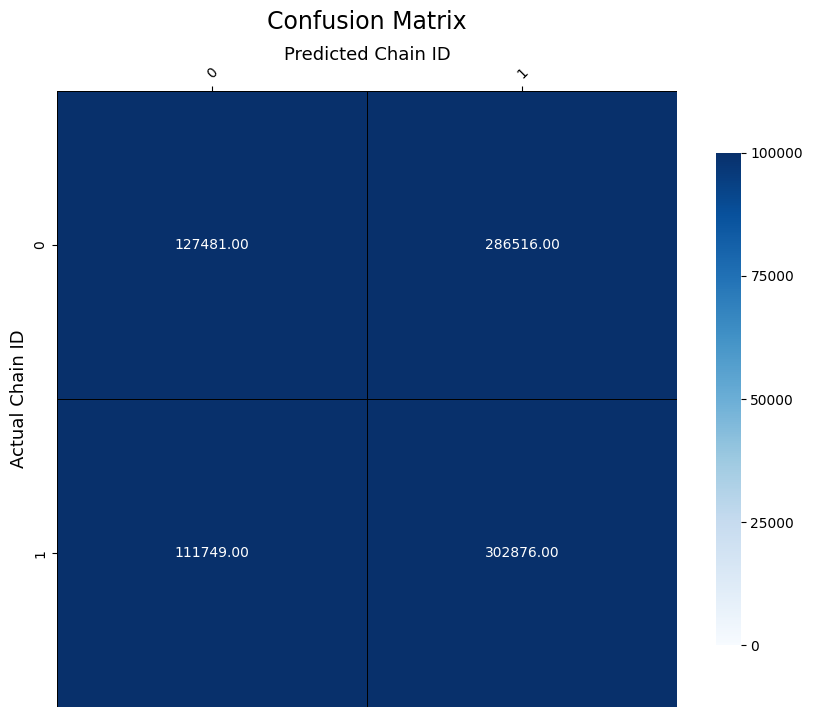

predictive accuracy: 0.5193646801557285

R*: 1.038729360311457

=====

Testing Results!

[[22651 81241]
 [38383 64881]]

2

length of id list:2

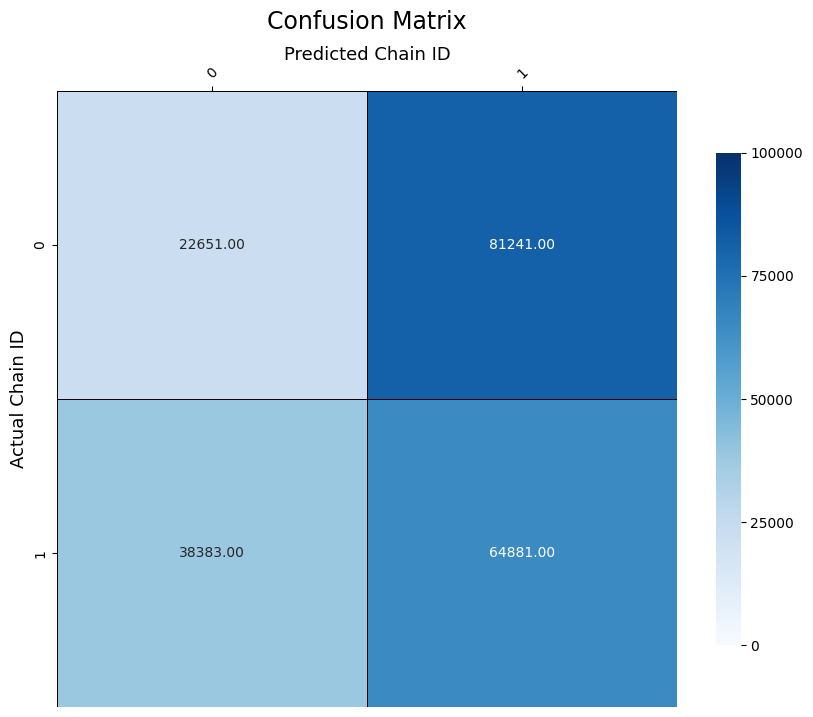

predictive accuracy: 0.4225414663345498

R*: 0.8450829326690996

=====

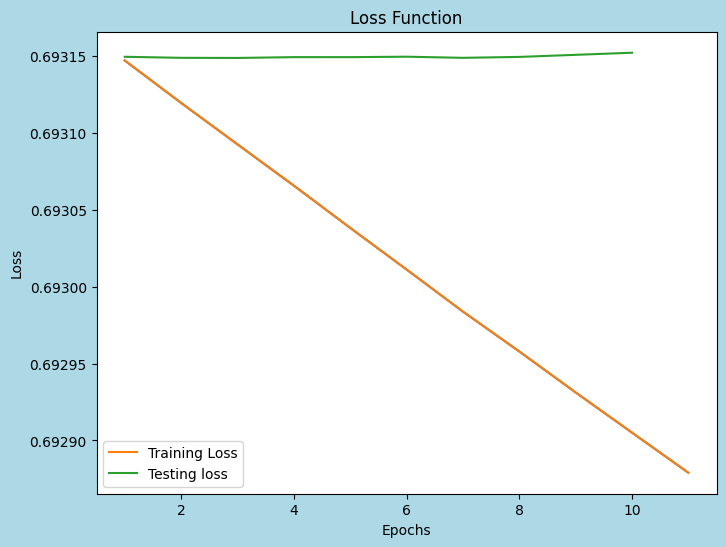

In [7]:
#test
path= Path("../models/demo_files 2/asimov_fits/identical test")

link=[f"{path}/{x}" for x in os.listdir(path)] 

print(link)
fitting_label = "ID"
paths = [link]

temp_asimov=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", 'xsec_6', 'xsec_7', 'xsec_8', 'xsec_9', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>10000"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()

        if lm == link:
            temp_asimov.append(chain_handler)



a22_j11=temp_asimov[0] 
a22_j11.ttree_array['ID']= 0

b22_j11= temp_asimov[1]
b22_j11.ttree_array['ID']=1

print(len(a22_j11.ttree_array))
print(len(b22_j11.ttree_array))
#print(len(a22_j11.ttree_array))

temporary_list_asimov = [a22_j11, b22_j11]

lengths = [n.ttree_array.shape[0] for n in temporary_list_asimov]
min_length = min(lengths)
b22_j11.ttree_array=b22_j11.ttree_array[:min_length]

print(len(a22_j11.ttree_array))
print(len(b22_j11.ttree_array))


a22_j11.ttree_array= pd.concat([a22_j11.ttree_array, b22_j11.ttree_array])

print(a22_j11.ttree_array)

#print(datas.ttree_array)

path.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists

ml_factory_asimov = MLFactory(a22_j11, fitting_label, f"{path}.pdf")

ml_model_asimov = ml_factory_asimov.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=20, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_asimov.set_training_test_set(0.2)

ml_model_asimov.train_model()
print('=========================')
print(f'results for identical:')
ml_model_asimov.test_model_class(2, norm= False, model=ml_model_asimov)


# NEW: All asimov fits 

['../models/demo_files 2/asimov_fits/asimov_all/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root', '../models/demo_files 2/asimov_fits/asimov_all/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root', '../models/demo_files 2/asimov_fits/asimov_all/trimmed_MaCh3-joint2021_asimovB22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root']
Attempting to open ../models/demo_files 2/asimov_fits/asimov_all/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root
Succesfully opened ../models/demo_files 2/asimov_fits/asimov_all/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root:posteriors
Using 12 threads and requiring 1.003 Gb memory
Using the following branches: 
  -> delm2_12
  -> delm2_23
  -> delta_cp
  -> sin2th_12
  -> sin2th_13
  -> sin2th_23
  -> xsec_0
  -> xsec_1
  -> xsec_10
  -> xsec_100
  -> xsec_101
  -> xsec_102
  

[[318511  45522  40277]
 [ 46481 317885  40001]
 [ 25717  26072 352414]]

3

length of id list:3

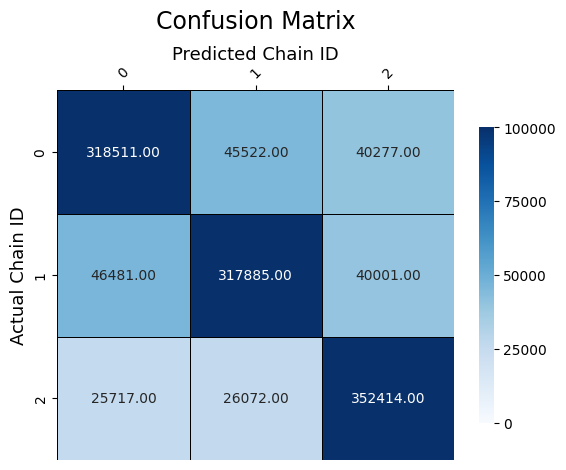

predictive accuracy: 0.8152578985555042

R*: 2.445773695666513

=====

Testing Results!

[[78883 11966 10208]
 [12287 78701 10012]
 [ 6641  6830 87693]]

3

length of id list:3

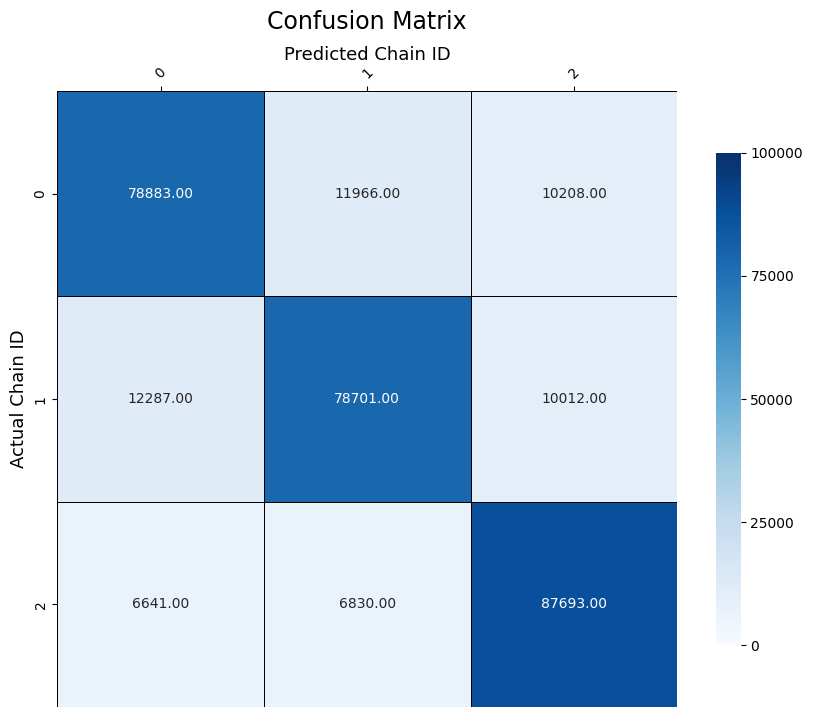

predictive accuracy: 0.8089050560482288

R*: 2.4267151681446864

=====

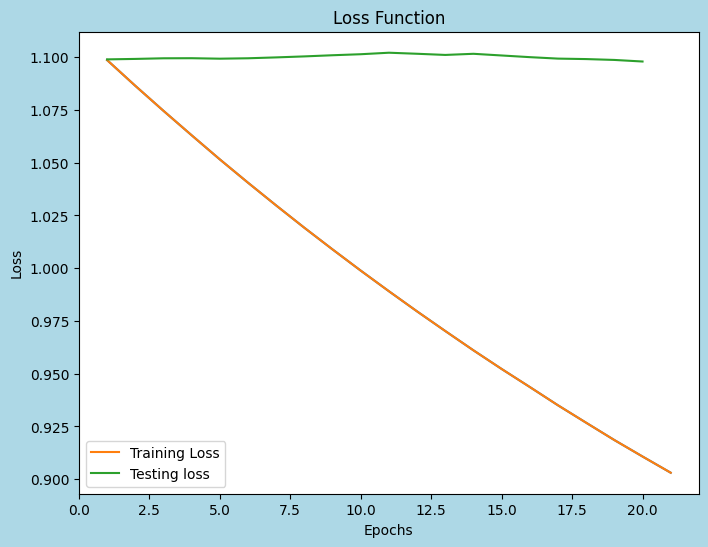

In [2]:
path= Path("../models/demo_files 2/asimov_fits/asimov_all")

link=[f"{path}/{x}" for x in os.listdir(path)] 

print(link)
fitting_label = "ID"
paths = [link]

temp_asimov=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", 'xsec_6', 'xsec_7', 'xsec_8', 'xsec_9', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>10000"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()

        if lm == link:
            temp_asimov.append(chain_handler)



a22_j11=temp_asimov[0] 
a22_j11.ttree_array['ID']= 0

b22_j11= temp_asimov[1]
b22_j11.ttree_array['ID']=1

third= temp_asimov[2]
third.ttree_array['ID']=2

print(len(a22_j11.ttree_array))
print(len(b22_j11.ttree_array))
print(len(third.ttree_array))

#print(len(a22_j11.ttree_array))
print(len(b22_j11.ttree_array))
temporary_list_asimov = [a22_j11, b22_j11, third]

lengths = [n.ttree_array.shape[0] for n in temporary_list_asimov]
min_length = min(lengths)
print(f'This is the min length: {min_length}')
b22_j11.ttree_array=b22_j11.ttree_array[:min_length]
third.ttree_array=third.ttree_array[:min_length]

print(len(a22_j11.ttree_array))
print(len(b22_j11.ttree_array))
print(len(third.ttree_array))



a22_j11.ttree_array= pd.concat([a22_j11.ttree_array, b22_j11.ttree_array])
a22_j11.ttree_array= pd.concat([a22_j11.ttree_array, third.ttree_array])




print(a22_j11.ttree_array)

#print(datas.ttree_array)

path.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists

ml_factory_asimov = MLFactory(a22_j11, fitting_label, f"{path}.pdf")

ml_model_asimov = ml_factory_asimov.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=20, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_asimov.set_training_test_set(0.2)

ml_model_asimov.train_model()
print('=========================')
print(f'results for identical:')
ml_model_asimov.test_model_class(3, norm= False, model=ml_model_asimov)


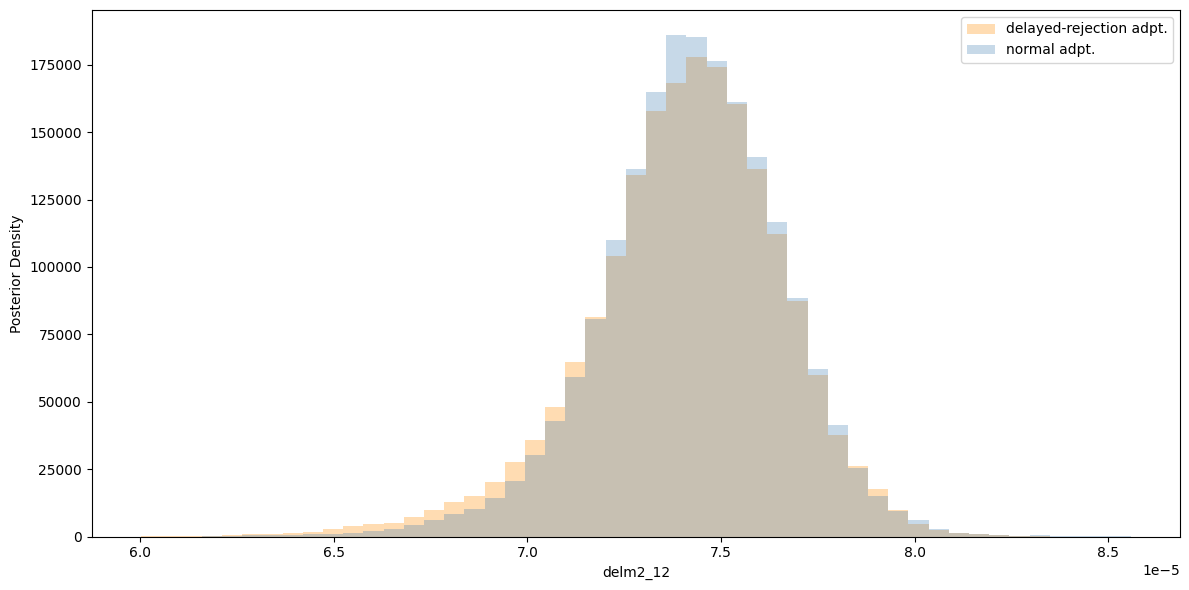

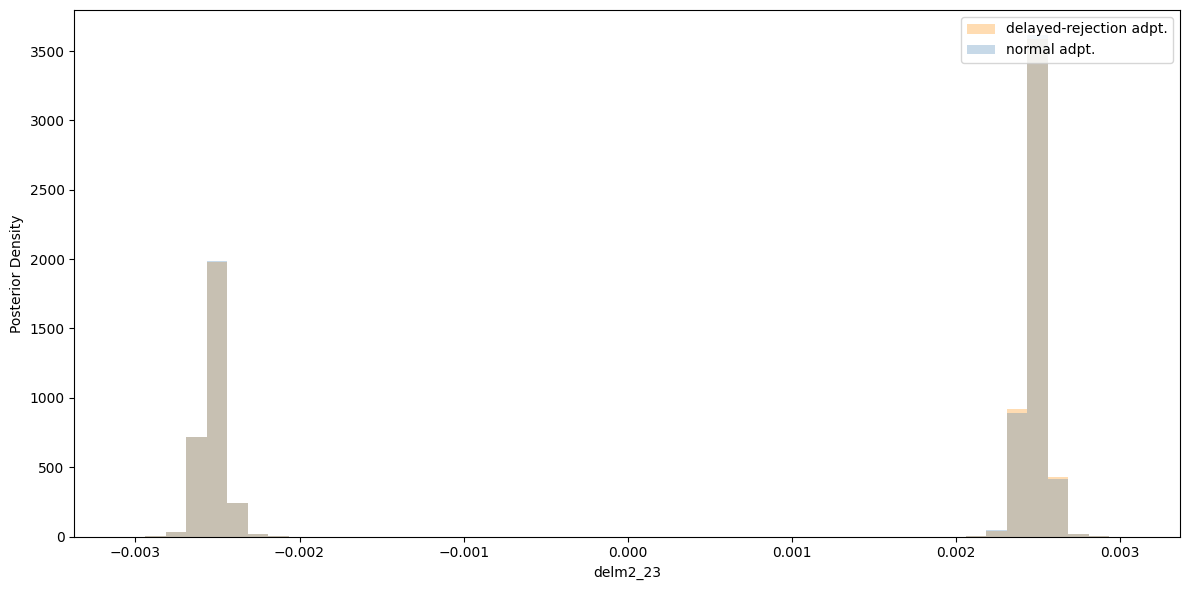

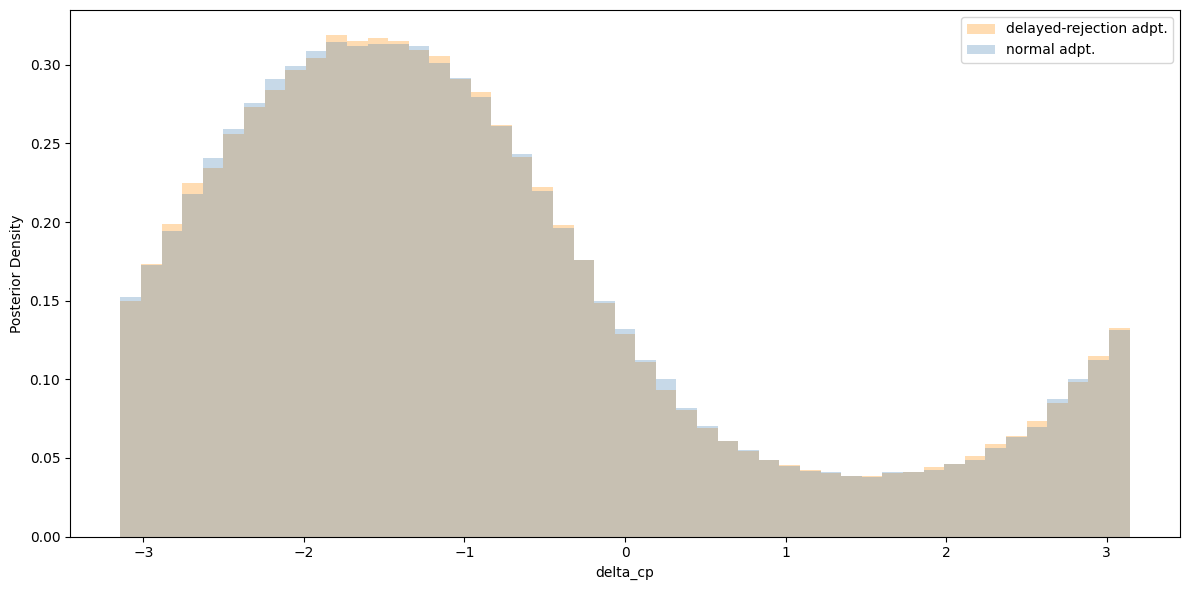

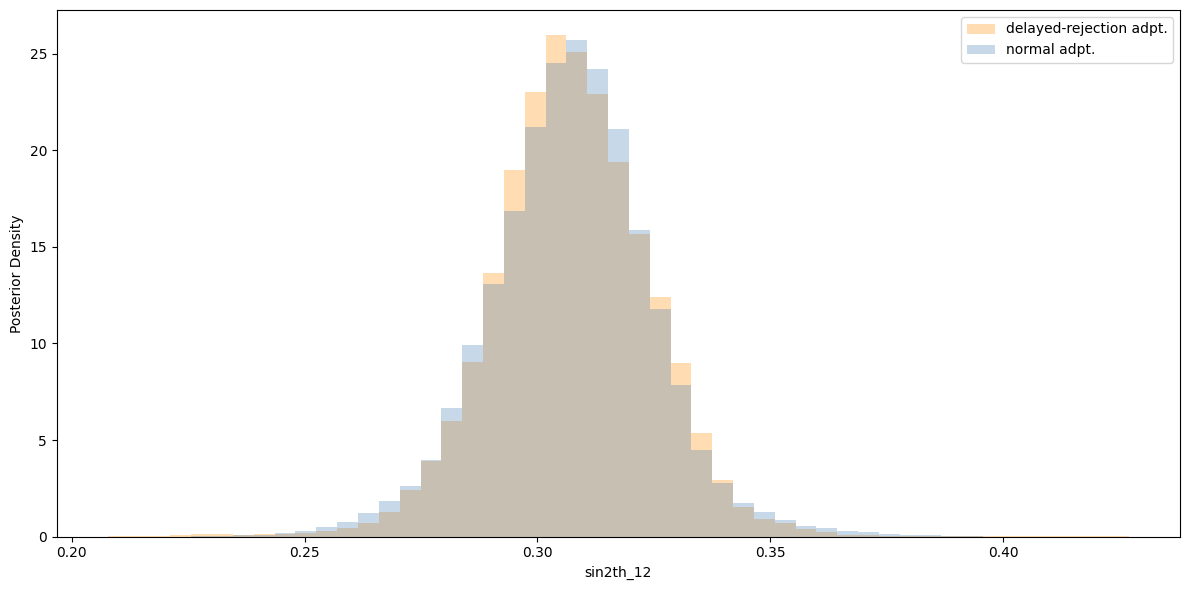

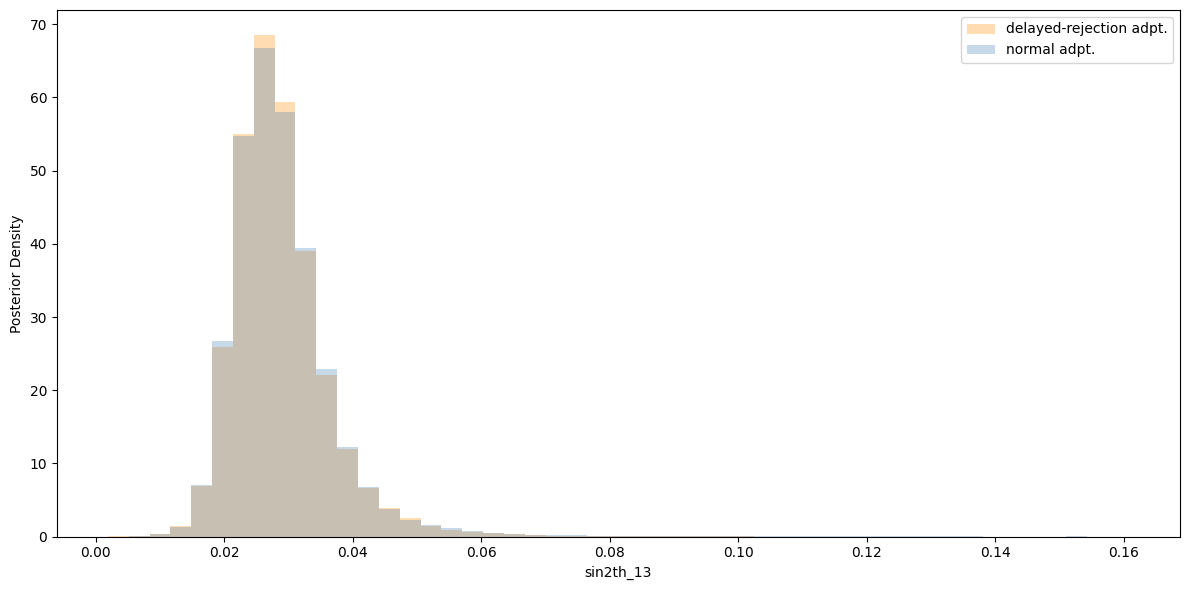

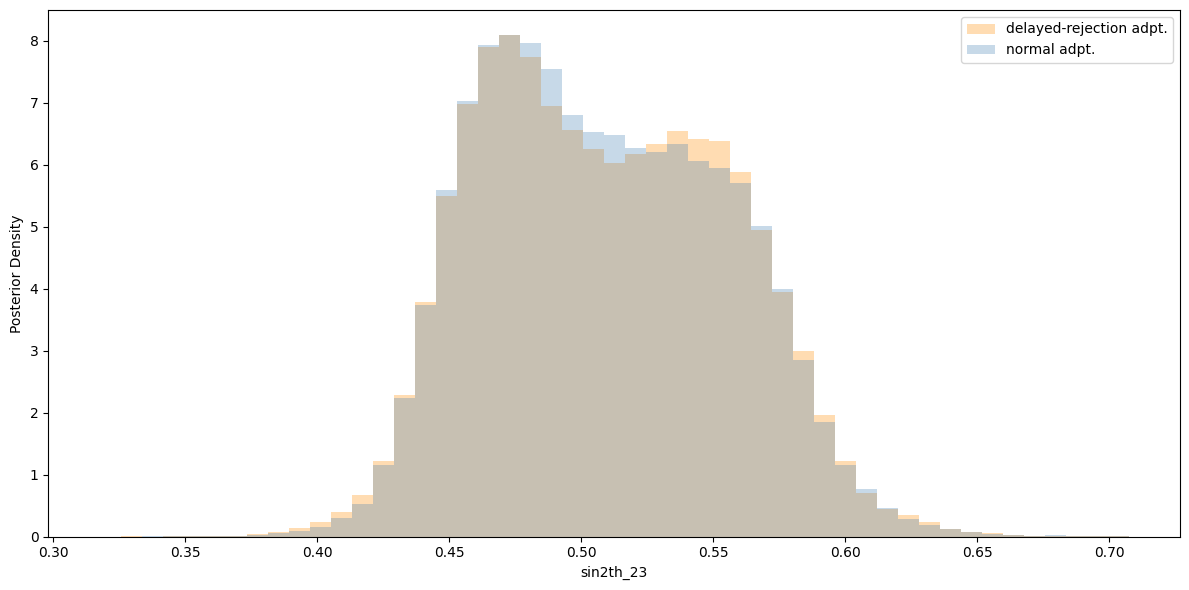

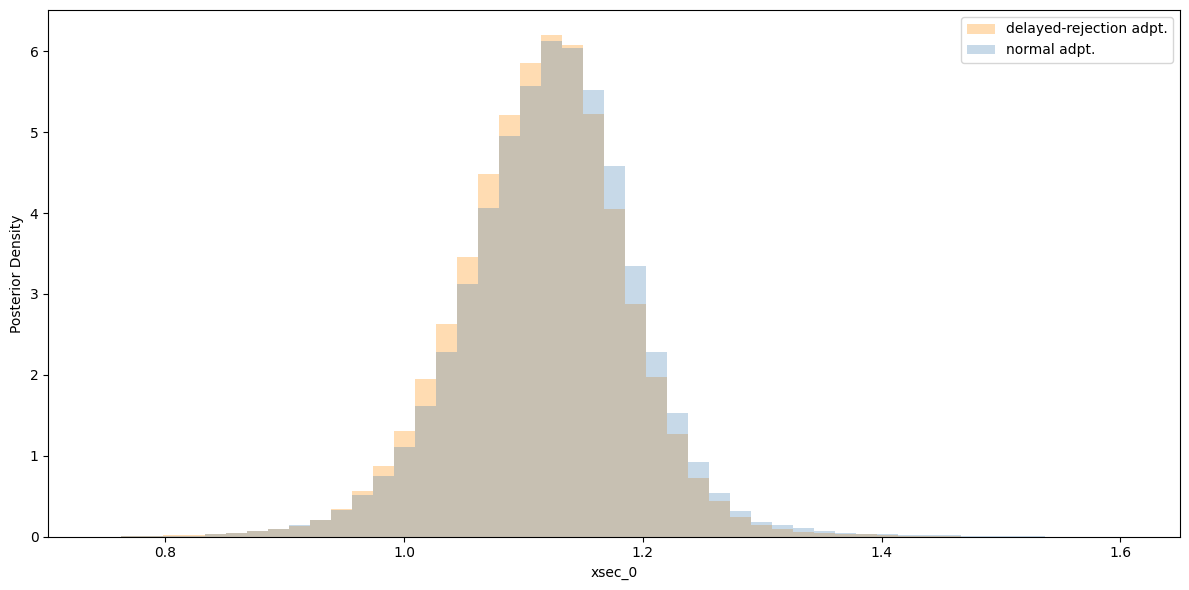

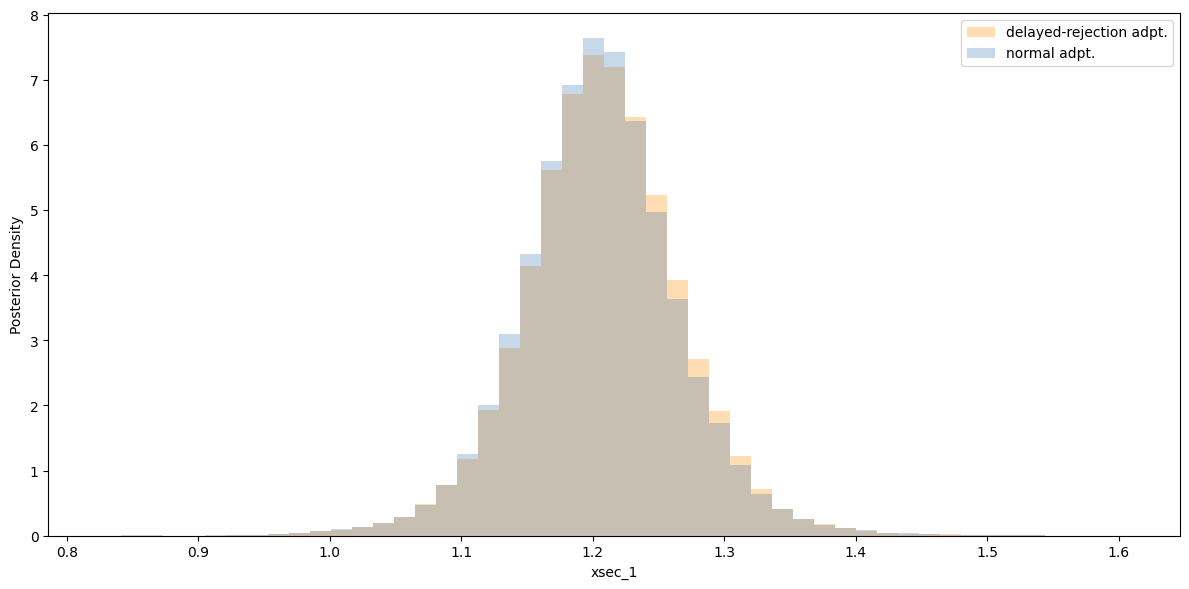

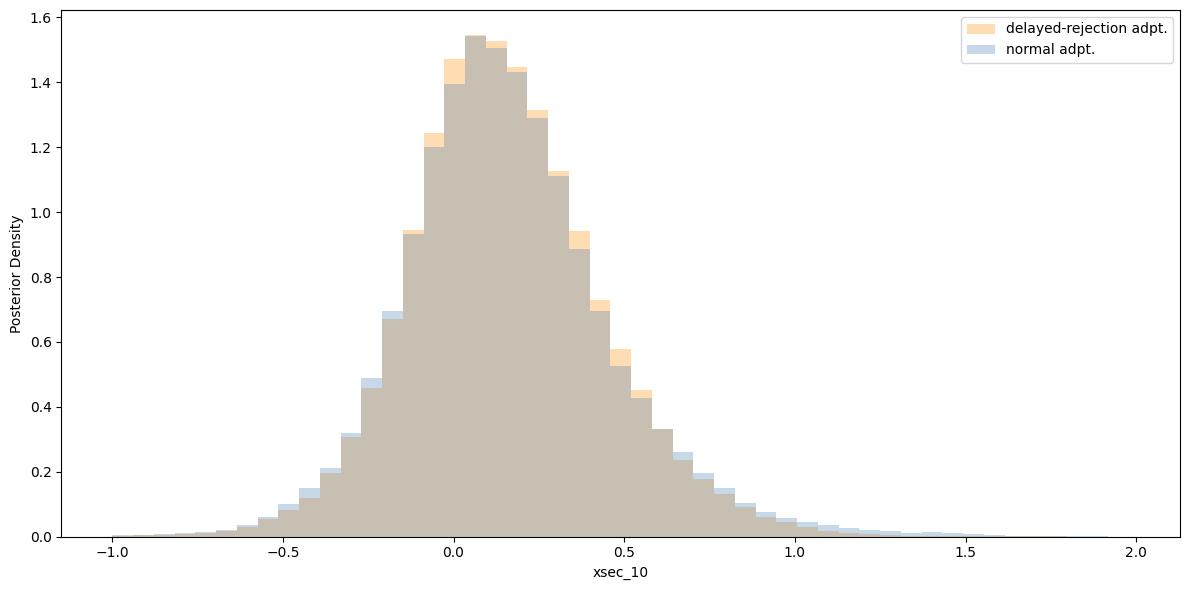

In [3]:
temp_asimov[0].ttree_array = temp_asimov[0].ttree_array[temp_asimov[0].ttree_array["ID"]==0]

for col in temp_asimov[0].ttree_array.columns:

    if col not in temp_asimov[1].ttree_array.columns:
        raise Exception(f"Error could not find {col}")

    plotter_delayed_corr=ChainDiagnostics(temp_asimov[0])
    plotter_mcmc_corr= ChainDiagnostics(temp_asimov[1])
    #plotter_delayed("xsec_0")
    #plotter_mcmc("xsec_0")
    #plt.show()

    delayed_corr_chain, paramname = plotter_delayed_corr._extract_chain_information(col)
    mcmc_corr_chain, paramname = plotter_mcmc_corr._extract_chain_information(col)

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))

    # ax[0].plot(delayed_chain, lw=0.5, label='delayed-rejection adpt.', color='darkorange')
    # ax[0].plot(mcmc_chain, lw=0.5, label='normal adpt.', color='steelblue')
    # ax[0].set_xlabel('Iteration')
    # ax[0].set_ylabel('Parameter value')


    bins = np.linspace(min(min(delayed_corr_chain), min(mcmc_corr_chain)), max(max(delayed_corr_chain), max(mcmc_corr_chain)), 50)

    ax.hist(delayed_corr_chain, bins=bins, lw=0.5, label='delayed-rejection adpt.', color='darkorange', density=True, alpha=0.3)
    ax.hist(mcmc_corr_chain, bins=bins, lw=0.5, label='normal adpt.', color='steelblue', density=True, alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_xlabel(col)
    ax.set_ylabel("Posterior Density")

    plt.tight_layout()
    plt.show()

    if col == 'xsec_10':
        break